# Corso di Sistemi di Elaborazione Accelerata

**Progetto d'Esame:** Accelerazione GPU per l'Analisi del Rischio Ambientale (Heat & Flood Risk)
**Studente:** Fabio Malagutti - 0001247400
**Anno Accademico:** 2025/2026

---

## Istruzioni per l'Esecuzione

Questo notebook implementa l'intera pipeline di elaborazione, partendo dai dati satellitari grezzi fino alla generazione delle mappe di rischio e dei report prestazionali.

### 1. Configurazione del Runtime
Per garantire la corretta esecuzione del codice CUDA e del profiling tramite Nsight Compute, è necessario selezionare l'acceleratore hardware appropriato:
* Navigare nel menu in alto: **Runtime** > **Cambia tipo di runtime**.
* Selezionare **T4 GPU**.

### 2. Caricamento dei File Sorgente
Per avviare la demo, è necessario caricare i seguenti archivi nella sezione file (barra laterale sinistra):
1.  **progetto.zip**: Contiene il codice sorgente C++ (`src/`) e gli script di automazione Python (`scripts/`).
2.  **test_1.zip**: Contiene il dataset di input (file GeoTIFF e GeoJSON).

*Nota: Non decomprimere i file manualmente. Lo script di inizializzazione (Fase 0) gestirà automaticamente l'estrazione e la configurazione delle directory di lavoro.*

### 3. Avvio
Una volta caricati gli archivi, eseguire tutte le celle in sequenza:
* Menu **Runtime** > **Esegui tutto** (Run all).

---

## Nota sulla Nomenclatura ("Fase 5")
Nel corso dell'esecuzione del notebook, verrà visualizzata la dicitura **"Phase 5: Functional Verification"**.
Tale numerazione deriva dalla pipeline di sviluppo incrementale adottata durante il progetto. Nel contesto di questo elaborato finale, essa identifica la fase di **Validazione Funzionale e Baseline**, durante la quale viene verificata la correttezza numerica dell'algoritmo (RMSE = 0.0) rispetto all'implementazione CPU, prima di procedere con i benchmark prestazionali avanzati.

## Descrizione del Dataset e Contesto di Riferimento

Il dataset utilizzato per questa analisi deriva dal progetto open source **TALEA - Analisi Isole di Calore di Superficie Urbana**, focalizzato sul monitoraggio delle dinamiche termiche nel Comune di Bologna durante la stagione estiva 2024.

L'acquisizione dei dati è stata effettuata mediante tecniche di telerilevamento satellitare (Remote Sensing), integrando rilevazioni multispettrali provenienti dalle costellazioni **Landsat 8/9** e **MODIS**. L'obiettivo del dataset originale è l'identificazione e la caratterizzazione del fenomeno delle Isole di Calore Urbane (UHI - Urban Heat Islands).

### Parametri Fisici e Variabili di Input
Ai fini del calcolo parallelo su GPU, sono stati selezionati i seguenti indicatori geospaziali raster (GeoTIFF), che costituiscono le matrici di input per gli algoritmi di stenciling:

* **Land Surface Temperature (LST):** Rappresenta la temperatura radiometrica della superficie terrestre (asfalto, coperture edili, suolo nudo). È il parametro primario per la localizzazione dei picchi termici.
* **Normalized Difference Vegetation Index (NDVI):** Indice spettrale che quantifica la presenza e lo stato di salute della vegetazione. Valori prossimi a 1 indicano vegetazione densa, mentre valori prossimi a 0 indicano superfici antropizzate o impermeabili.
* **Albedo:** Coefficiente di riflettività della superficie (Broadband Albedo). Indica la frazione di radiazione solare incidente che viene riflessa; superfici a basso albedo (scure) tendono ad assorbire maggiore energia termica.
* **Indicatori Compositi:** Il dataset include metriche derivate quali l'*Urban Heat Exposure Index* (UHEI) e l'*Heat Retention Index*, calcolati combinando LST, NDVI e proprietà dei materiali per evidenziare le aree a maggior rischio di stress ambientale.

### Specifiche Tecniche
I dati sono forniti georeferenziati e ritagliati sui confini amministrativi di Bologna. Le matrici raster presentano una risoluzione spaziale compatibile con i sensori Landsat (30m/pixel), fornendo una granularità sufficiente per l'analisi a scala di quartiere richiesta dalla simulazione CUDA.

In [ ]:
import os
import shutil
from google.colab import files

print("=====================================================================")
print("[SETUP] PHASE 0: ENVIRONMENT CONFIGURATION AND DATA PREPARATION")
print("=====================================================================")

# 1. Pulizia ambiente precedente
print("[INFO] Cleaning previous environment artifacts...")
!rm -rf src scripts bin reports progetto __MACOSX *.bin *.png *.html *.csv *.tif *.geojson

# 2. Verifica File di Input
if not os.path.exists("progetto.zip") or not os.path.exists("test_1.zip"):
    print("[WARN] Input archives not found. Please upload 'progetto.zip' and 'test_1.zip'.")
    # uploaded = files.upload() # Uncomment for manual upload

# 3. Estrazione Codice Sorgente
if os.path.exists("progetto.zip"):
    print("[INFO] Extracting source code archive...")
    !unzip -q -o progetto.zip

    # --- HANDLING SUBDIRECTORY STRUCTURE ---
    if os.path.exists("progetto") and os.path.isdir("progetto"):
        print("[INFO] Detected nested 'progetto/' directory. Relocating files to root...")
        # Copia contenuto in root
        !cp -r progetto/* .
        # Cleanup cartelle temporanee
        !rm -rf progetto __MACOSX

    # Permessi di esecuzione
    if os.path.exists("scripts"):
        !chmod +x scripts/*.py
        print("[INFO] Execution permissions granted to Python scripts.")
    else:
        print("[ERROR] 'scripts' directory not found after extraction.")
else:
    print("[ERROR] Critical: 'progetto.zip' is missing.")

# 4. Estrazione Dataset
if os.path.exists("test_1.zip"):
    print("[INFO] Extracting satellite data (GeoTIFF/GeoJSON)...")
    !unzip -q -o test_1.zip

    print("[INFO] Normalizing data file paths...")
    # Spostamento file dalle sottocartelle alla root (Logic preserved)
    !find . -name "*.tif" ! -path "./*.tif" -exec mv {} . \; 2>/dev/null
    !find . -name "*.geojson" ! -path "./*.geojson" -exec mv {} . \; 2>/dev/null
else:
    print("[ERROR] Critical: 'test_1.zip' is missing.")

# 5. Configurazione Directory Output
print("[INFO] Creating output directories (bin/, reports/)...")
os.makedirs("bin", exist_ok=True)
os.makedirs("reports", exist_ok=True)

# 6. Installazione Dipendenze
print("[INFO] Installing GIS dependencies (rasterio, folium)...")
!pip install rasterio folium > /dev/null 2>&1

print("\n[SUCCESS] Environment setup complete. Verifying structure:")
print("---------------------------------------------------------------------")
!ls -F

[SETUP] PHASE 0: ENVIRONMENT CONFIGURATION AND DATA PREPARATION
[INFO] Cleaning previous environment artifacts...
[INFO] Extracting source code archive...
[INFO] Detected nested 'progetto/' directory. Relocating files to root...
[INFO] Execution permissions granted to Python scripts.
[INFO] Extracting satellite data (GeoTIFF/GeoJSON)...
[INFO] Normalizing data file paths...
[INFO] Creating output directories (bin/, reports/)...
[INFO] Installing GIS dependencies (rasterio, folium)...

[SUCCESS] Environment setup complete. Verifying structure:
---------------------------------------------------------------------
albedo_mean.tif		 __MACOSX/	     reports/	   test_1.zip
bin/			 ndvi_mean.tif	     sample_data/
bologna_borders.geojson  Nsight_Reports.zip  scripts/
lst_mean.tif		 progetto.zip	     src/


In [ ]:
print("=====================================================================")
print("[PHASE 1] DATA PREPROCESSING AND NORMALIZATION")
print("=====================================================================")

print("[INFO] Initiating raw data conversion pipeline (GeoTIFF/GeoJSON -> Binary)...")
print("[EXEC] Running 'scripts/data_preprocessor.py'...")

# Esecuzione dello script di preprocessing
!python3 scripts/data_preprocessor.py

print("[SUCCESS] Data preprocessing completed.")

[PHASE 1] DATA PREPROCESSING AND NORMALIZATION
[INFO] Initiating raw data conversion pipeline (GeoTIFF/GeoJSON -> Binary)...
[EXEC] Running 'scripts/data_preprocessor.py'...
[INFO] Starting data preprocessing (TIFF -> BIN)
[INFO] Target dimensions (based on NDVI): 758 x 502

[INFO] Processing input files...
[INFO] NDVI dimensions OK (758x502).
[INFO] Saved: input_ndvi.bin (1.45 MB)
[INFO] Resizing LST (228x151 -> 758x502)...
[INFO] Saved: input_lst.bin (1.45 MB)
[INFO] ALB dimensions OK (758x502).
[INFO] Saved: input_albedo.bin (1.45 MB)

[RESULTS] CUDA configuration summary:
Ensure the .cu file includes:
#define WIDTH  758
#define HEIGHT 502
[SUCCESS] Data preprocessing completed.


In [ ]:
print("=====================================================================")
print("[PHASE 5] FUNCTIONAL VERIFICATION AND BASELINE BENCHMARK")
print("=====================================================================")

print("[INFO] Objective: Validation of numerical correctness (RMSE = 0.0) and baseline performance.")
print("[INFO] Compiling 'src/risk_map_generator.cu'...")
print("[EXEC] Running 'scripts/run_phase5_benchmark.py'...")

# Esecuzione benchmark funzionale
!python3 scripts/run_phase5_benchmark.py

print("[SUCCESS] Functional verification completed.")

[PHASE 5] FUNCTIONAL VERIFICATION AND BASELINE BENCHMARK
[INFO] Objective: Validation of numerical correctness (RMSE = 0.0) and baseline performance.
[INFO] Compiling 'src/risk_map_generator.cu'...
[EXEC] Running 'scripts/run_phase5_benchmark.py'...
[INFO] Phase 5: Functional Verification and Baseline
[INFO] GPU Target: Tesla T4

[INFO] Running preliminary benchmark...

[RESULTS] Phase 5 Summary
+----------+------------+------------+----------+--------------+--------------+----------+
| BLOCK    | CPU (ms)   | GPU (ms)   | SPEEDUP  | RMSE         | MAX_ERR      | STATUS   |
+----------+------------+------------+----------+--------------+--------------+----------+
| 8x8     | 4.030      | 0.187      | 21.6  x | 0.00e+00     | 0.00e+00     | PASSED   |
| 16x16    | 4.361      | 0.166      | 26.2  x | 0.00e+00     | 0.00e+00     | PASSED   |
| 32x32    | 3.989      | 0.223      | 17.9  x | 0.00e+00     | 0.00e+00     | PASSED   |
+----------+------------+------------+----------+----------

In [ ]:
print("=====================================================================")
print("[PHASE 6] LATENCY ANALYSIS AND PINNED MEMORY OPTIMIZATION")
print("=====================================================================")

print("[INFO] Objective: Analyze Host-to-Device transfer latency and Bandwidth utilization.")
print("[INFO] Comparison Target: Pageable Memory vs. Pinned Memory.")
print("[EXEC] Running 'scripts/run_phase6_optimization.py'...")

# Esecuzione analisi ottimizzazione memoria
!python3 scripts/run_phase6_optimization.py

print("[SUCCESS] Latency and Bandwidth analysis completed.")

[PHASE 6] LATENCY ANALYSIS AND PINNED MEMORY OPTIMIZATION
[INFO] Objective: Analyze Host-to-Device transfer latency and Bandwidth utilization.
[INFO] Comparison Target: Pageable Memory vs. Pinned Memory.
[EXEC] Running 'scripts/run_phase6_optimization.py'...
[INFO] Phase 6: Latency and Bandwidth Analysis (32x32 vs 16x16)
+----------+------------+------------------+----------------------+------------+
| CONFIG   | TIME (ms)  | BANDWIDTH (GB/s) | THROUGHPUT (GPix/s)  | RMSE       |
+----------+------------+------------------+----------------------+------------+
| 32x32    | 0.10128    | 60.11            | 3.76                 | 1.28e-06   |
| 16x16    | 0.10474    | 58.13            | 3.63                 | 1.28e-06   |
+----------+------------+------------------+----------------------+------------+
[SUCCESS] Latency and Bandwidth analysis completed.


In [ ]:
print("=====================================================================")
print("[PHASE 7] COMPREHENSIVE PERFORMANCE BENCHMARKING")
print("=====================================================================")

print("[INFO] Objective: System-wide performance characterization (Kernel vs. Transfer).")
print("[INFO] Metrics: Speedup, Latency (Single-shot), Throughput (Batch), and Transfer Overhead.")
print("[EXEC] Running 'scripts/run_mega_benchmark.py'...")

# Esecuzione della suite completa
!python3 scripts/run_mega_benchmark.py

print("[SUCCESS] Benchmark data collected and saved to 'final_results.csv'.")

[PHASE 7] COMPREHENSIVE PERFORMANCE BENCHMARKING
[INFO] Objective: System-wide performance characterization (Kernel vs. Transfer).
[INFO] Metrics: Speedup, Latency (Single-shot), Throughput (Batch), and Transfer Overhead.
[EXEC] Running 'scripts/run_mega_benchmark.py'...
[INFO] Ultimate Benchmark: CPU vs NAIVE vs SHARED vs OPTIMIZED
[INFO] Validation, Speedup, Latency, Batch Analysis
[INFO] GPU: Tesla T4 (-arch=sm_75)
[INFO] Source: src/benchmark_suite.cu

+----------------------+----------+-----------------------------------------------+
| CONFIGURATION        | STATUS   | DETAILS (Avg 5 runs)                          |
+----------------------+----------+-----------------------------------------------+
| Naive (32x32)        | PASSED   | Kernel:  0.098 ms | Total:  2.540 ms | Transfer:  2.442 ms |
+----------------------+----------+-----------------------------------------------+
| Shared (8x8)         | PASSED   | Kernel:  0.122 ms | Total:  2.566 ms | Transfer:  2.444 ms |
+--------

In [ ]:
print("=====================================================================")
print("[PHASE EXTRA] KERNEL MICRO-OPTIMIZATION AND STRESS TESTING")
print("=====================================================================")

print("[INFO] Objective: Evaluate impact of low-level optimizations (Loop Unrolling, __restrict__) on Memory-Bound kernels.")
print("[INFO] Methodology: Comparative stress test (1000 iterations) - Standard vs. Extreme implementation.")
print("[EXEC] Running 'scripts/run_tuning_extreme.py'...")

# Esecuzione del tuning estremo
!python3 scripts/run_tuning_extreme.py

print("[SUCCESS] Micro-benchmark comparison completed.")

[PHASE EXTRA] KERNEL MICRO-OPTIMIZATION AND STRESS TESTING
[INFO] Objective: Evaluate impact of low-level optimizations (Loop Unrolling, __restrict__) on Memory-Bound kernels.
[INFO] Methodology: Comparative stress test (1000 iterations) - Standard vs. Extreme implementation.
[EXEC] Running 'scripts/run_tuning_extreme.py'...
[INFO] Deathmatch: Naive Standard vs Naive Extreme (Batch 1000)
[INFO] GPU: Tesla T4 (-arch=sm_75)
[INFO] Source: src/kernel_tuning_extreme.cu

[INFO] Compiling battle...
[INFO] Running battle (1000 iterations)...
+-----------------+----------+
| Kernel          | Time (ms) |
+-----------------+----------+
| Standard        | 42.410   |
| Extreme         | 40.057   |
+-----------------+----------+
[RESULTS] Delta: -2.353 ms (-5.55%)
[NOTE] This stencil is memory-bound; low-level optimizations typically yield limited gains.
[SUCCESS] Micro-benchmark comparison completed.


In [ ]:
print("=====================================================================")
print("[PHASE 8] KERNEL PROFILING AND MICRO-ARCHITECTURE ANALYSIS")
print("=====================================================================")

print("[INFO] Objective: High-resolution analysis using NVIDIA Nsight Compute (ncu).")
print("[INFO] Targets: Instruction Throughput, Memory Workload Analysis (L1/L2/DRAM), and Occupancy.")
print("[EXEC] Running 'scripts/run_nsight_profiling.py'...")

# Esecuzione del profiling
!python3 scripts/run_nsight_profiling.py

print("[SUCCESS] Profiling reports (.ncu-rep) generated and archived in 'reports/' directory.")

[PHASE 8] KERNEL PROFILING AND MICRO-ARCHITECTURE ANALYSIS
[INFO] Objective: High-resolution analysis using NVIDIA Nsight Compute (ncu).
[INFO] Targets: Instruction Throughput, Memory Workload Analysis (L1/L2/DRAM), and Occupancy.
[EXEC] Running 'scripts/run_nsight_profiling.py'...
[INFO] Phase 8: Nsight Compute Report Generation
[INFO] Memory and Compute Throughput Analysis
[INFO] GPU: Tesla T4 (-arch=sm_75)

[INFO] Compiling binaries for profiling...

[INFO] Profiling: NAIVE (Global Memory)...
[RESULTS] Report saved to: reports/report_01_naive.ncu-rep

[INFO] Profiling: SHARED (Standard)...
[RESULTS] Report saved to: reports/report_02_shared.ncu-rep

[INFO] Profiling: SHARED (Optimized)...
[RESULTS] Report saved to: reports/report_03_optimized.ncu-rep

[INFO] Archiving reports...
[INFO] Download 'Nsight_Reports.zip' and open it with Nsight Compute GUI.
[SUCCESS] Profiling reports (.ncu-rep) generated and archived in 'reports/' directory.


[PHASE 9-12] ANALYTICAL VISUALIZATION AND REPORT GENERATION
[INFO] Executing plotting scripts to generate static artifacts...
[SUCCESS] All charts generated. Rendering gallery below.
---------------------------------------------------------------------

[DISPLAY] 2. System Bottleneck Analysis (PCIe Overhead)
          [Source: Impact_of_Data_Transfer.png]


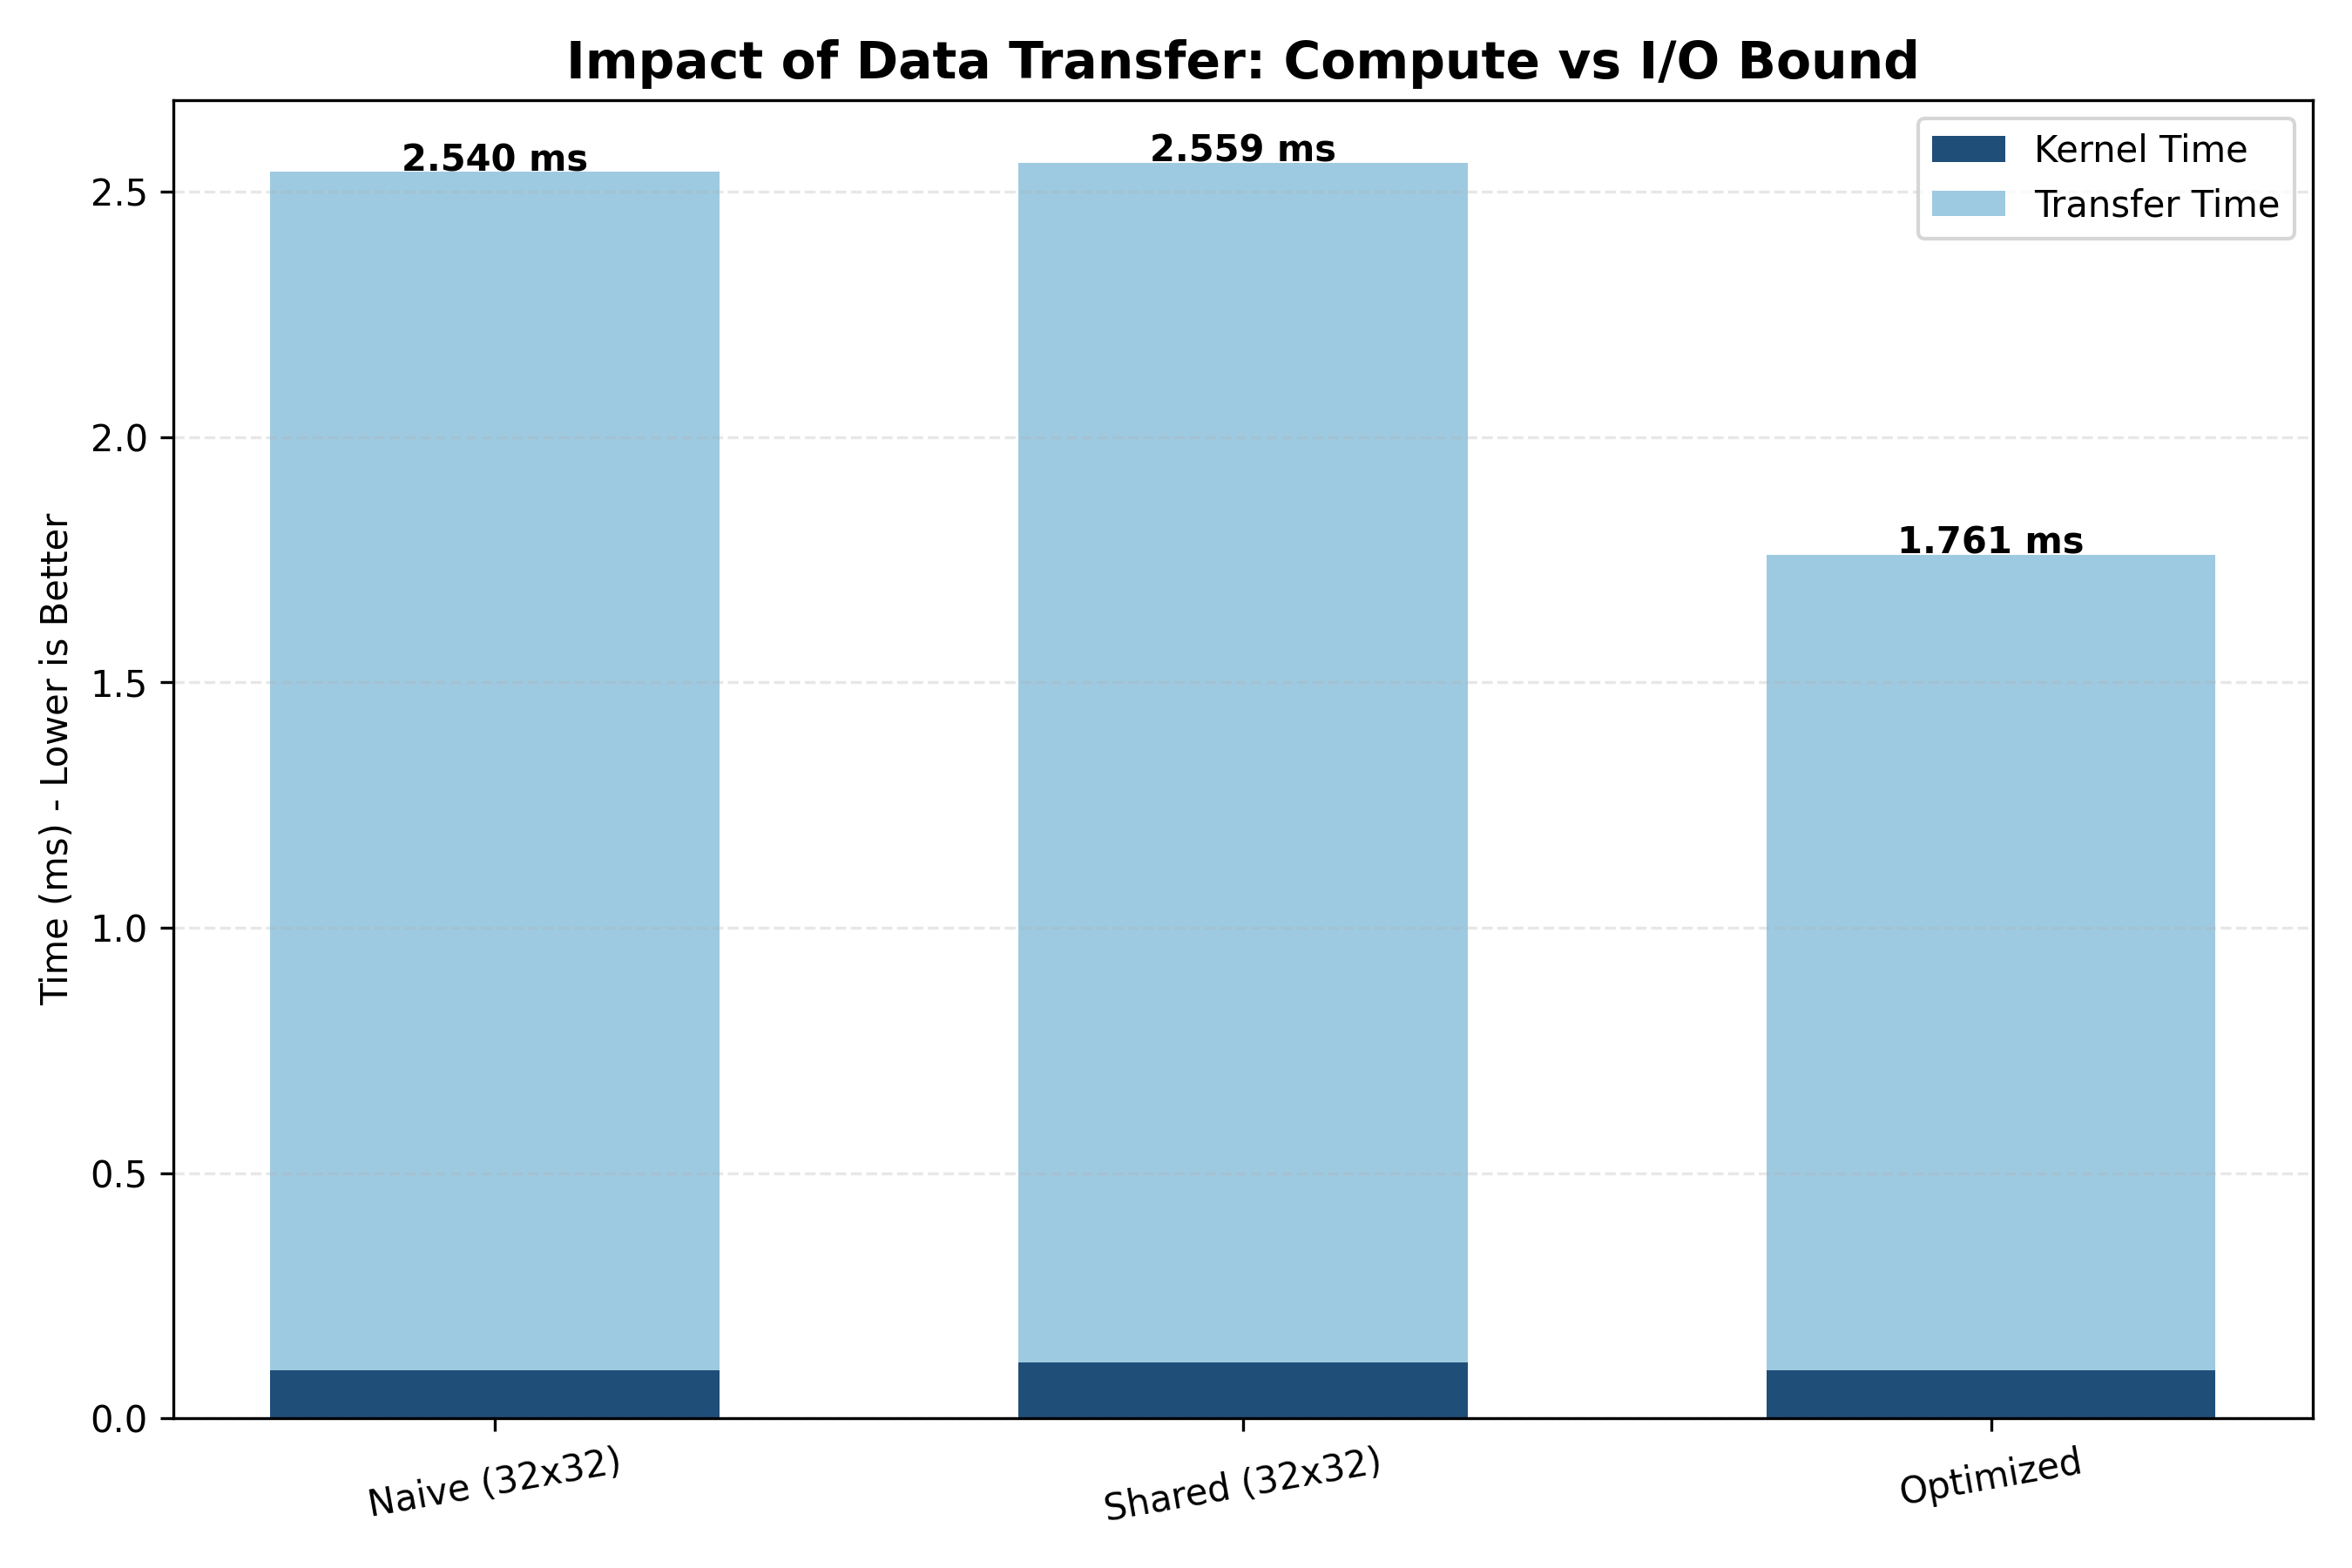


[DISPLAY] 3. Block Size Sensitivity Analysis (Occupancy)
          [Source: Chart_1_Sensitivity.png]


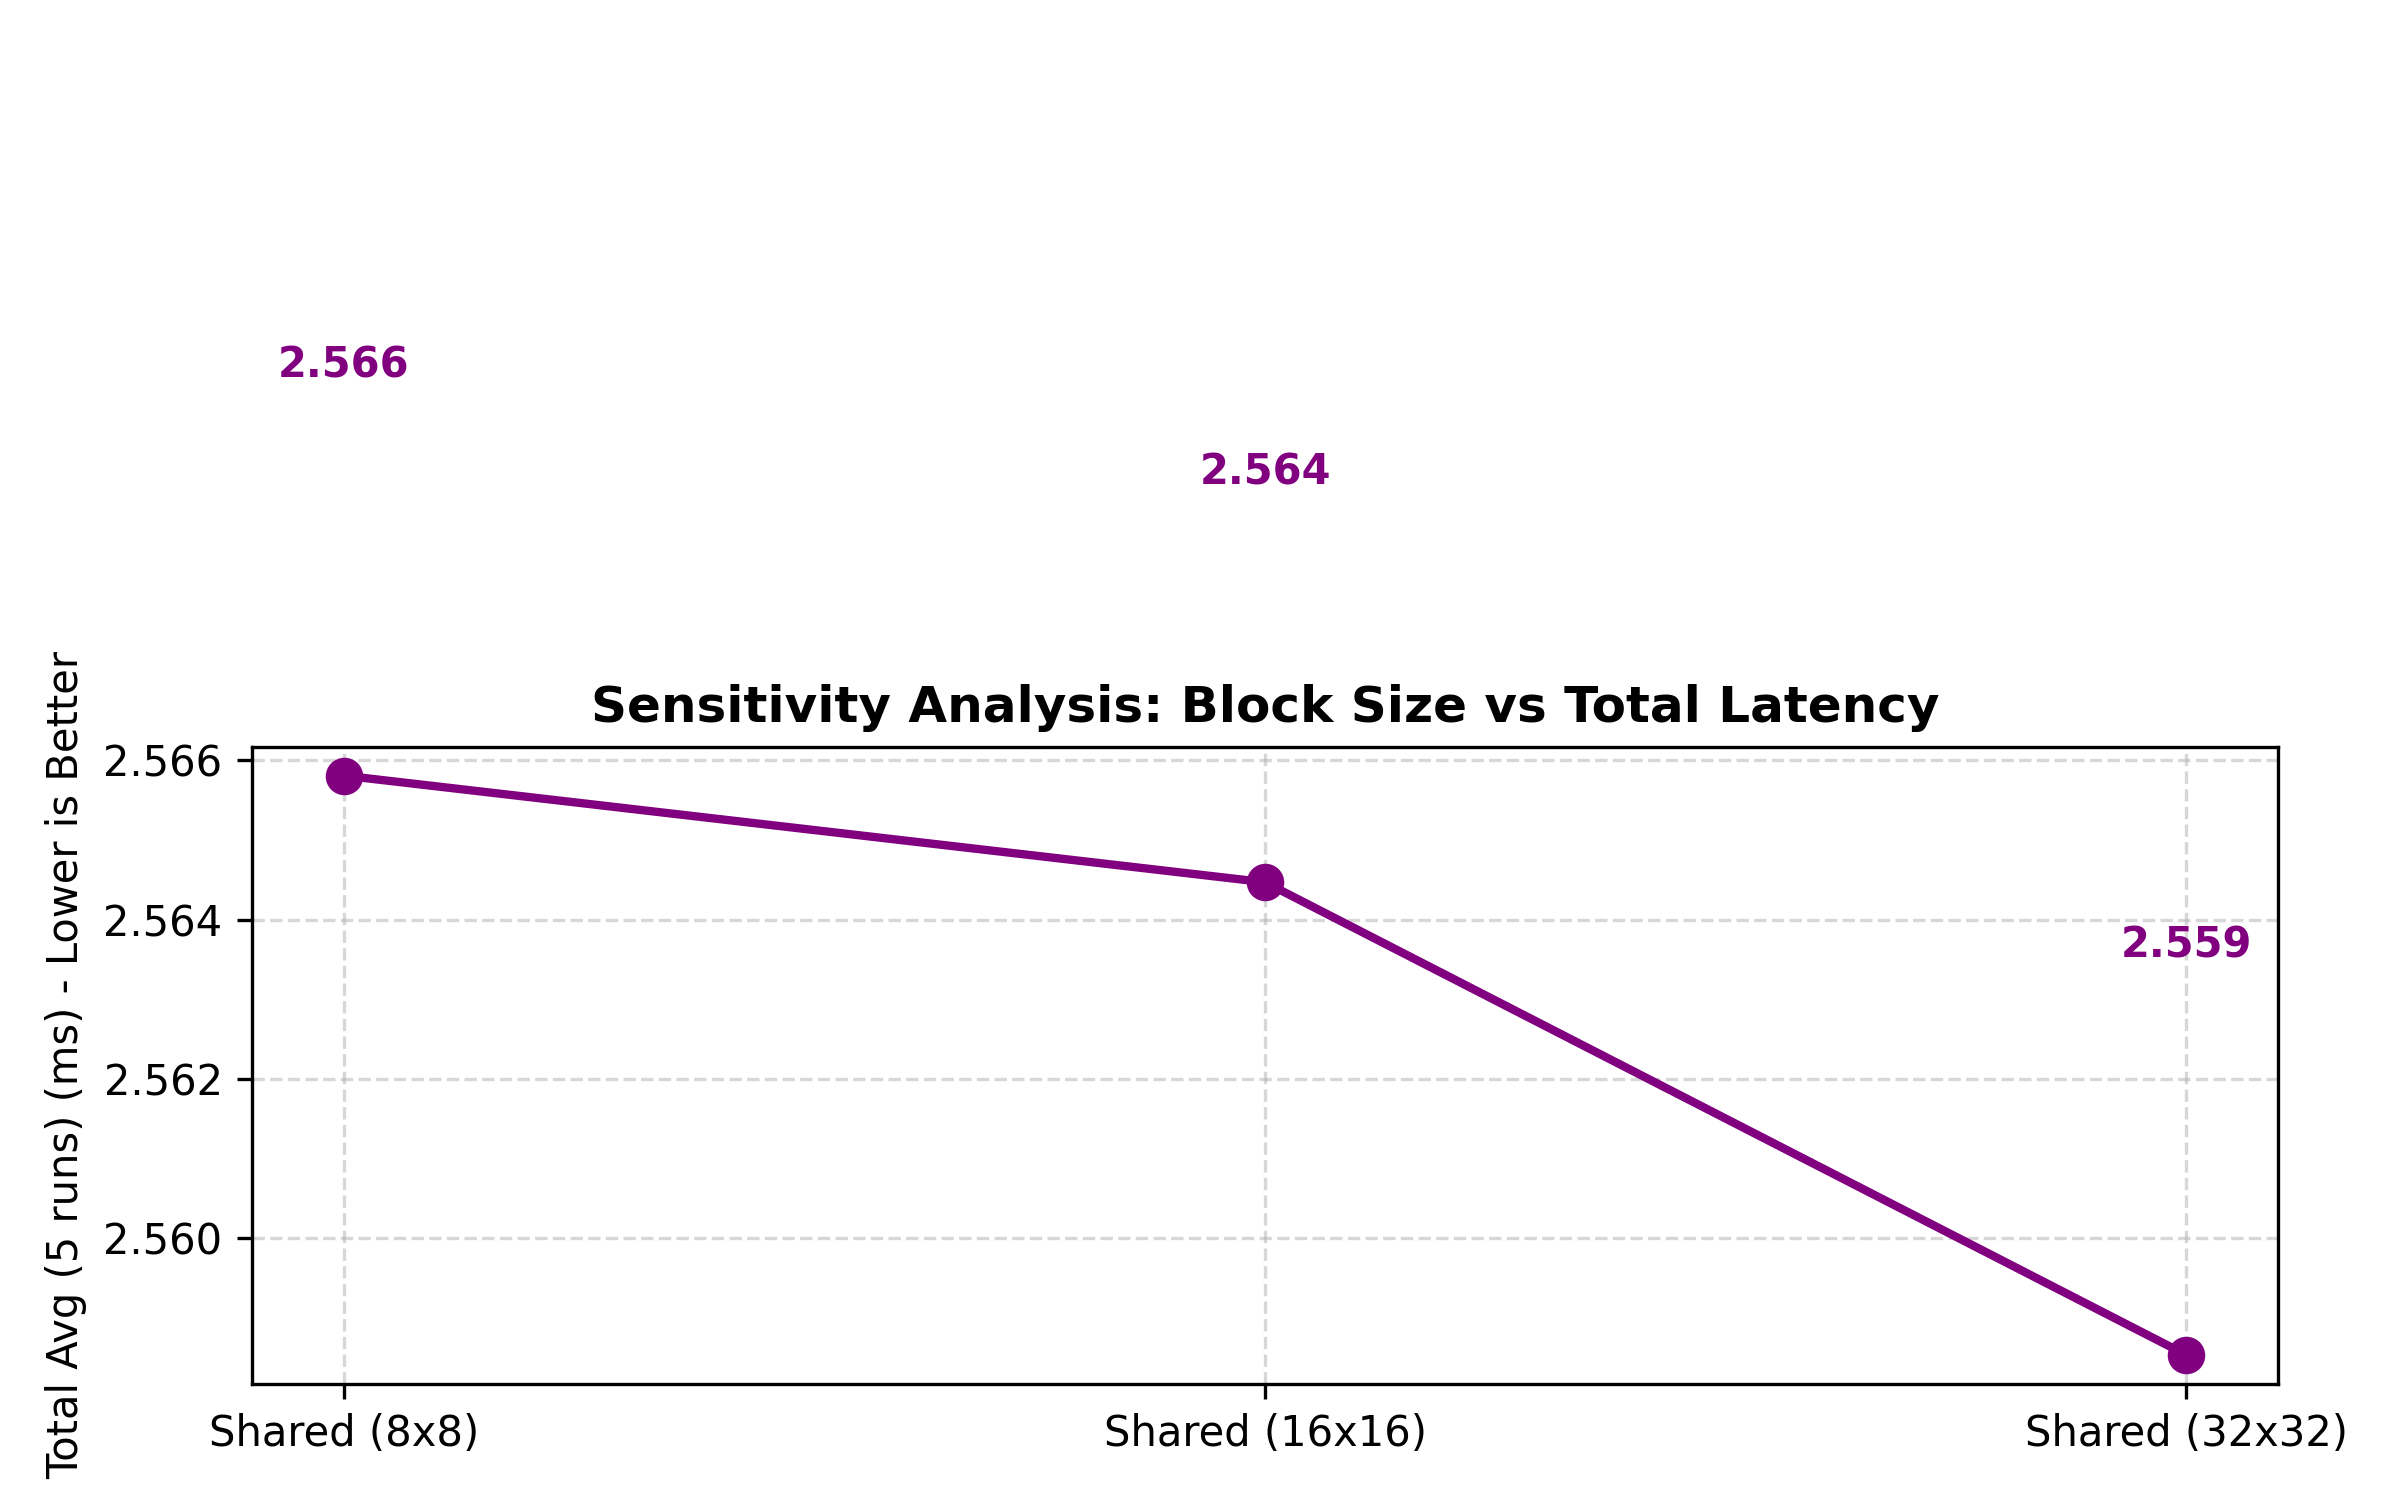


[DISPLAY] 4. Latency vs. Throughput Trade-off
          [Source: Chart_3_Tradeoff.png]


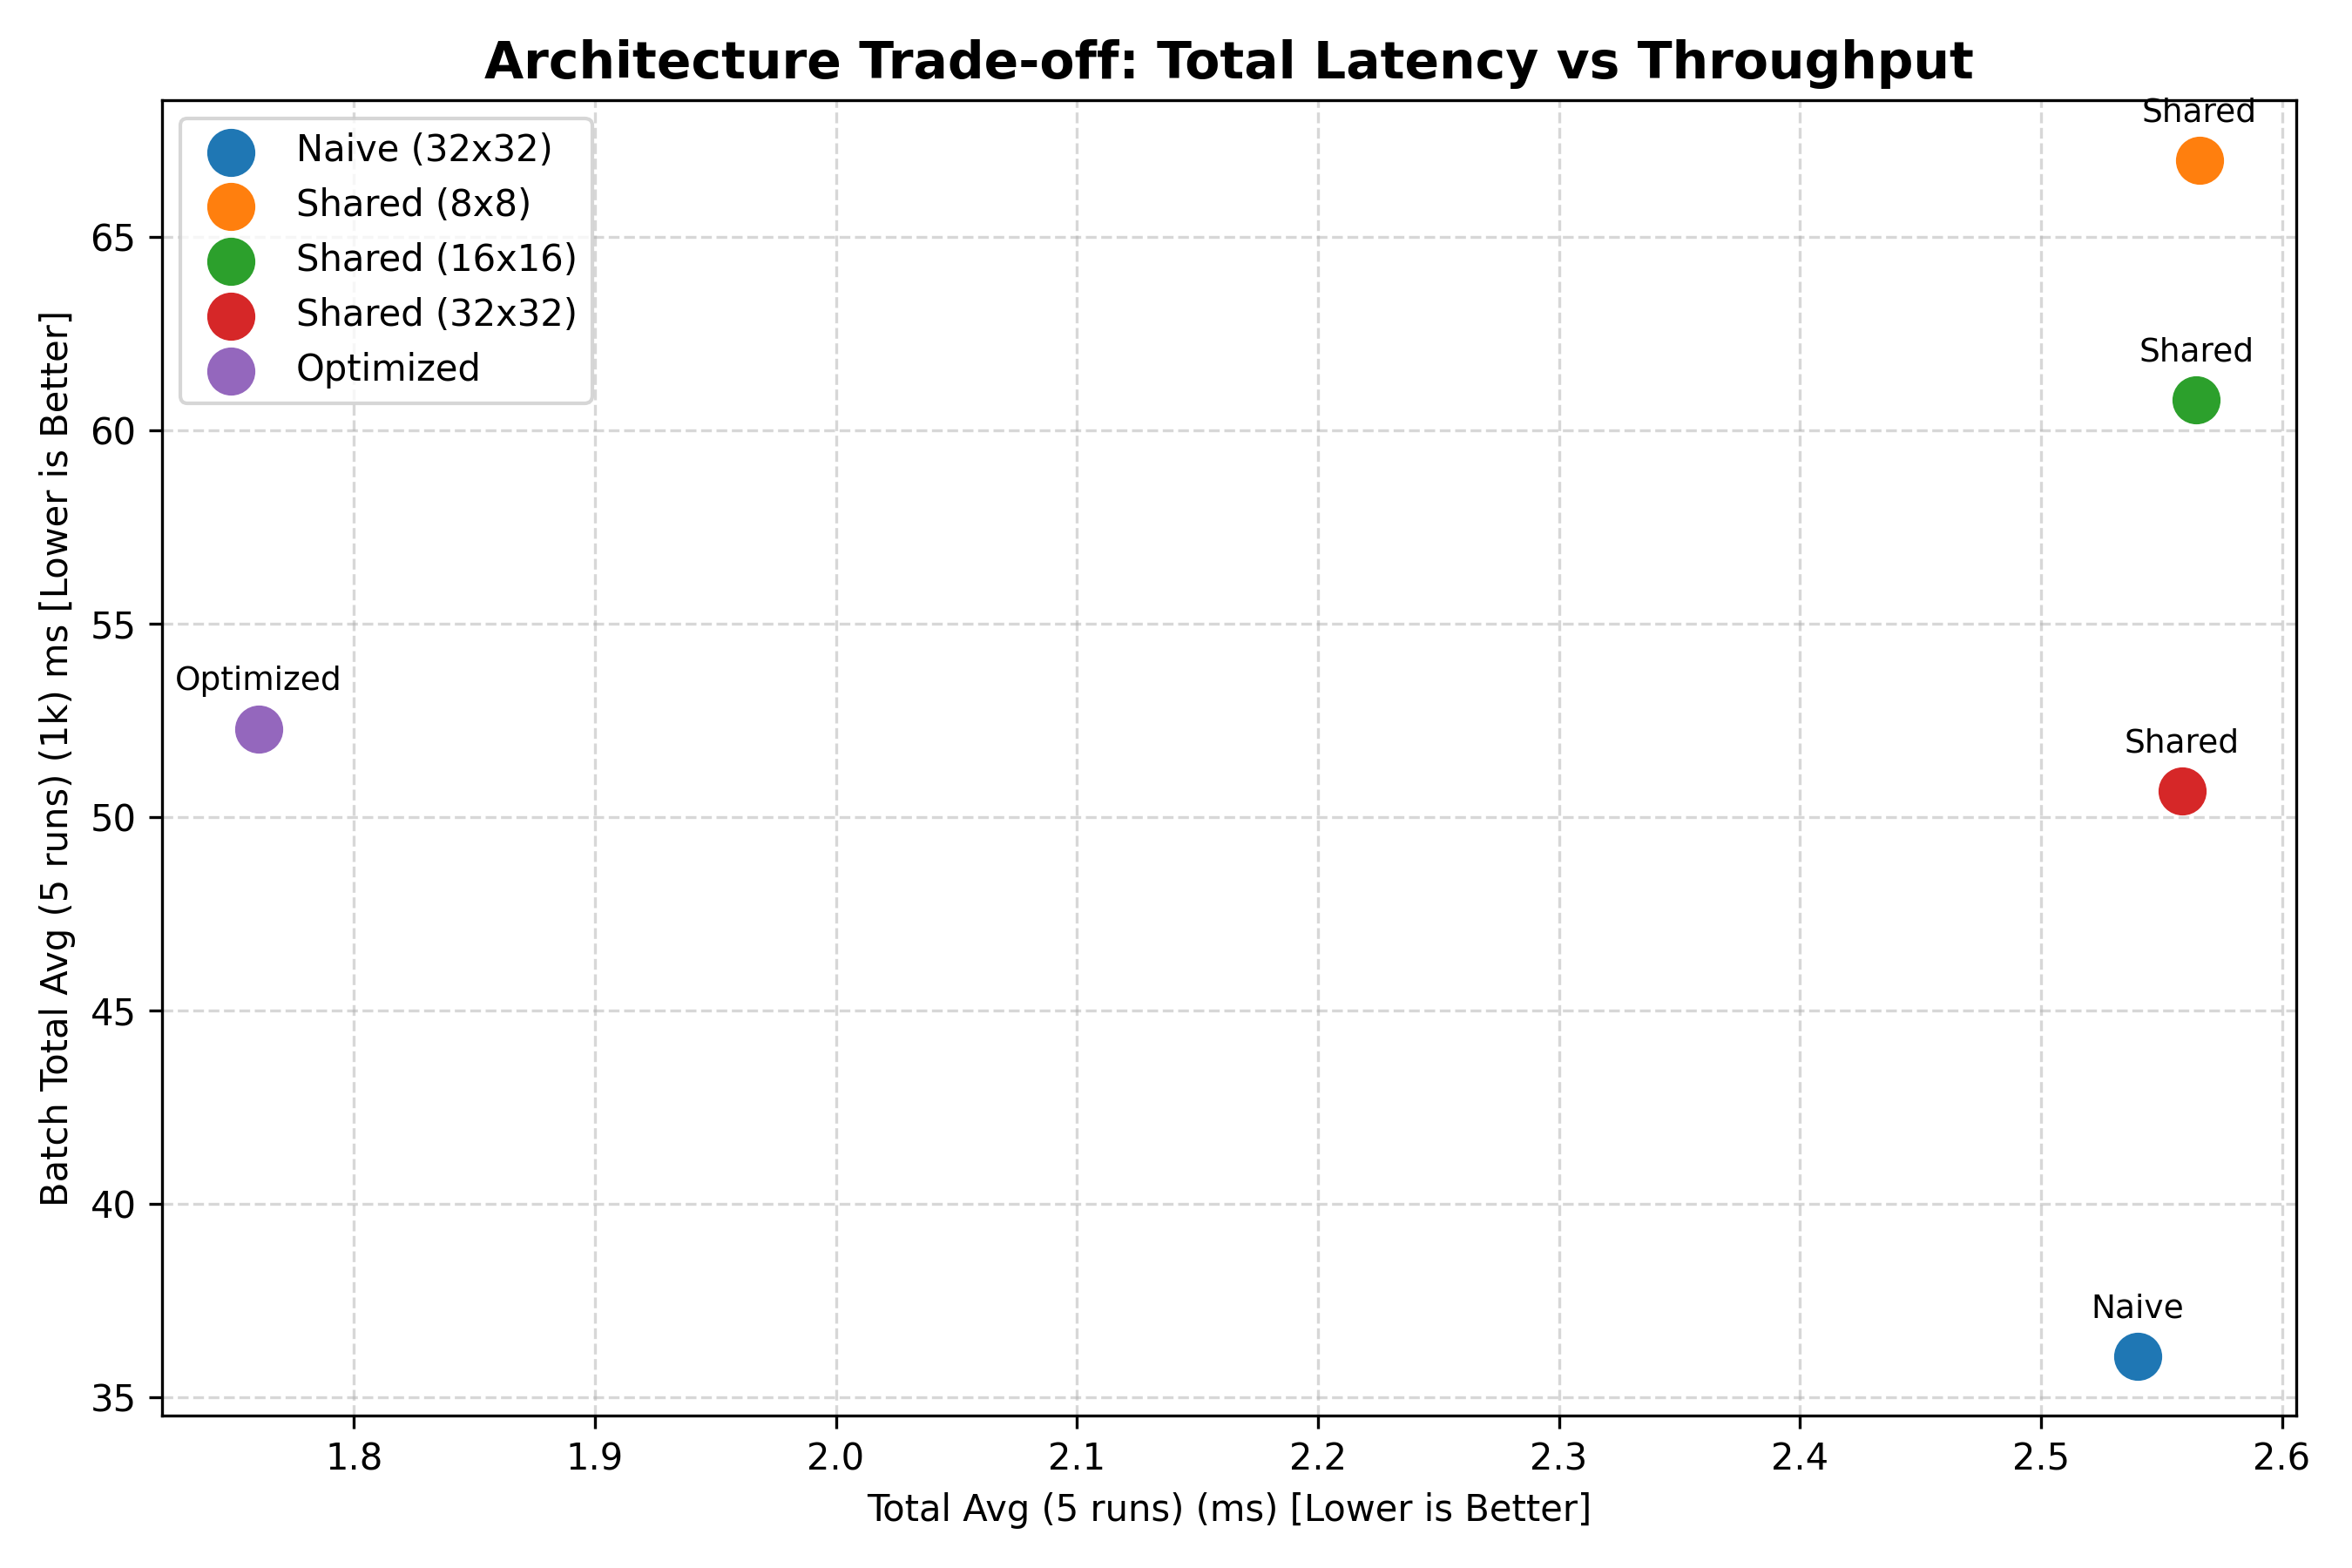


[DISPLAY] 5. Throughput Benchmark (Frames Per Second)
          [Source: Chart_2_Throughput_FPS.png]


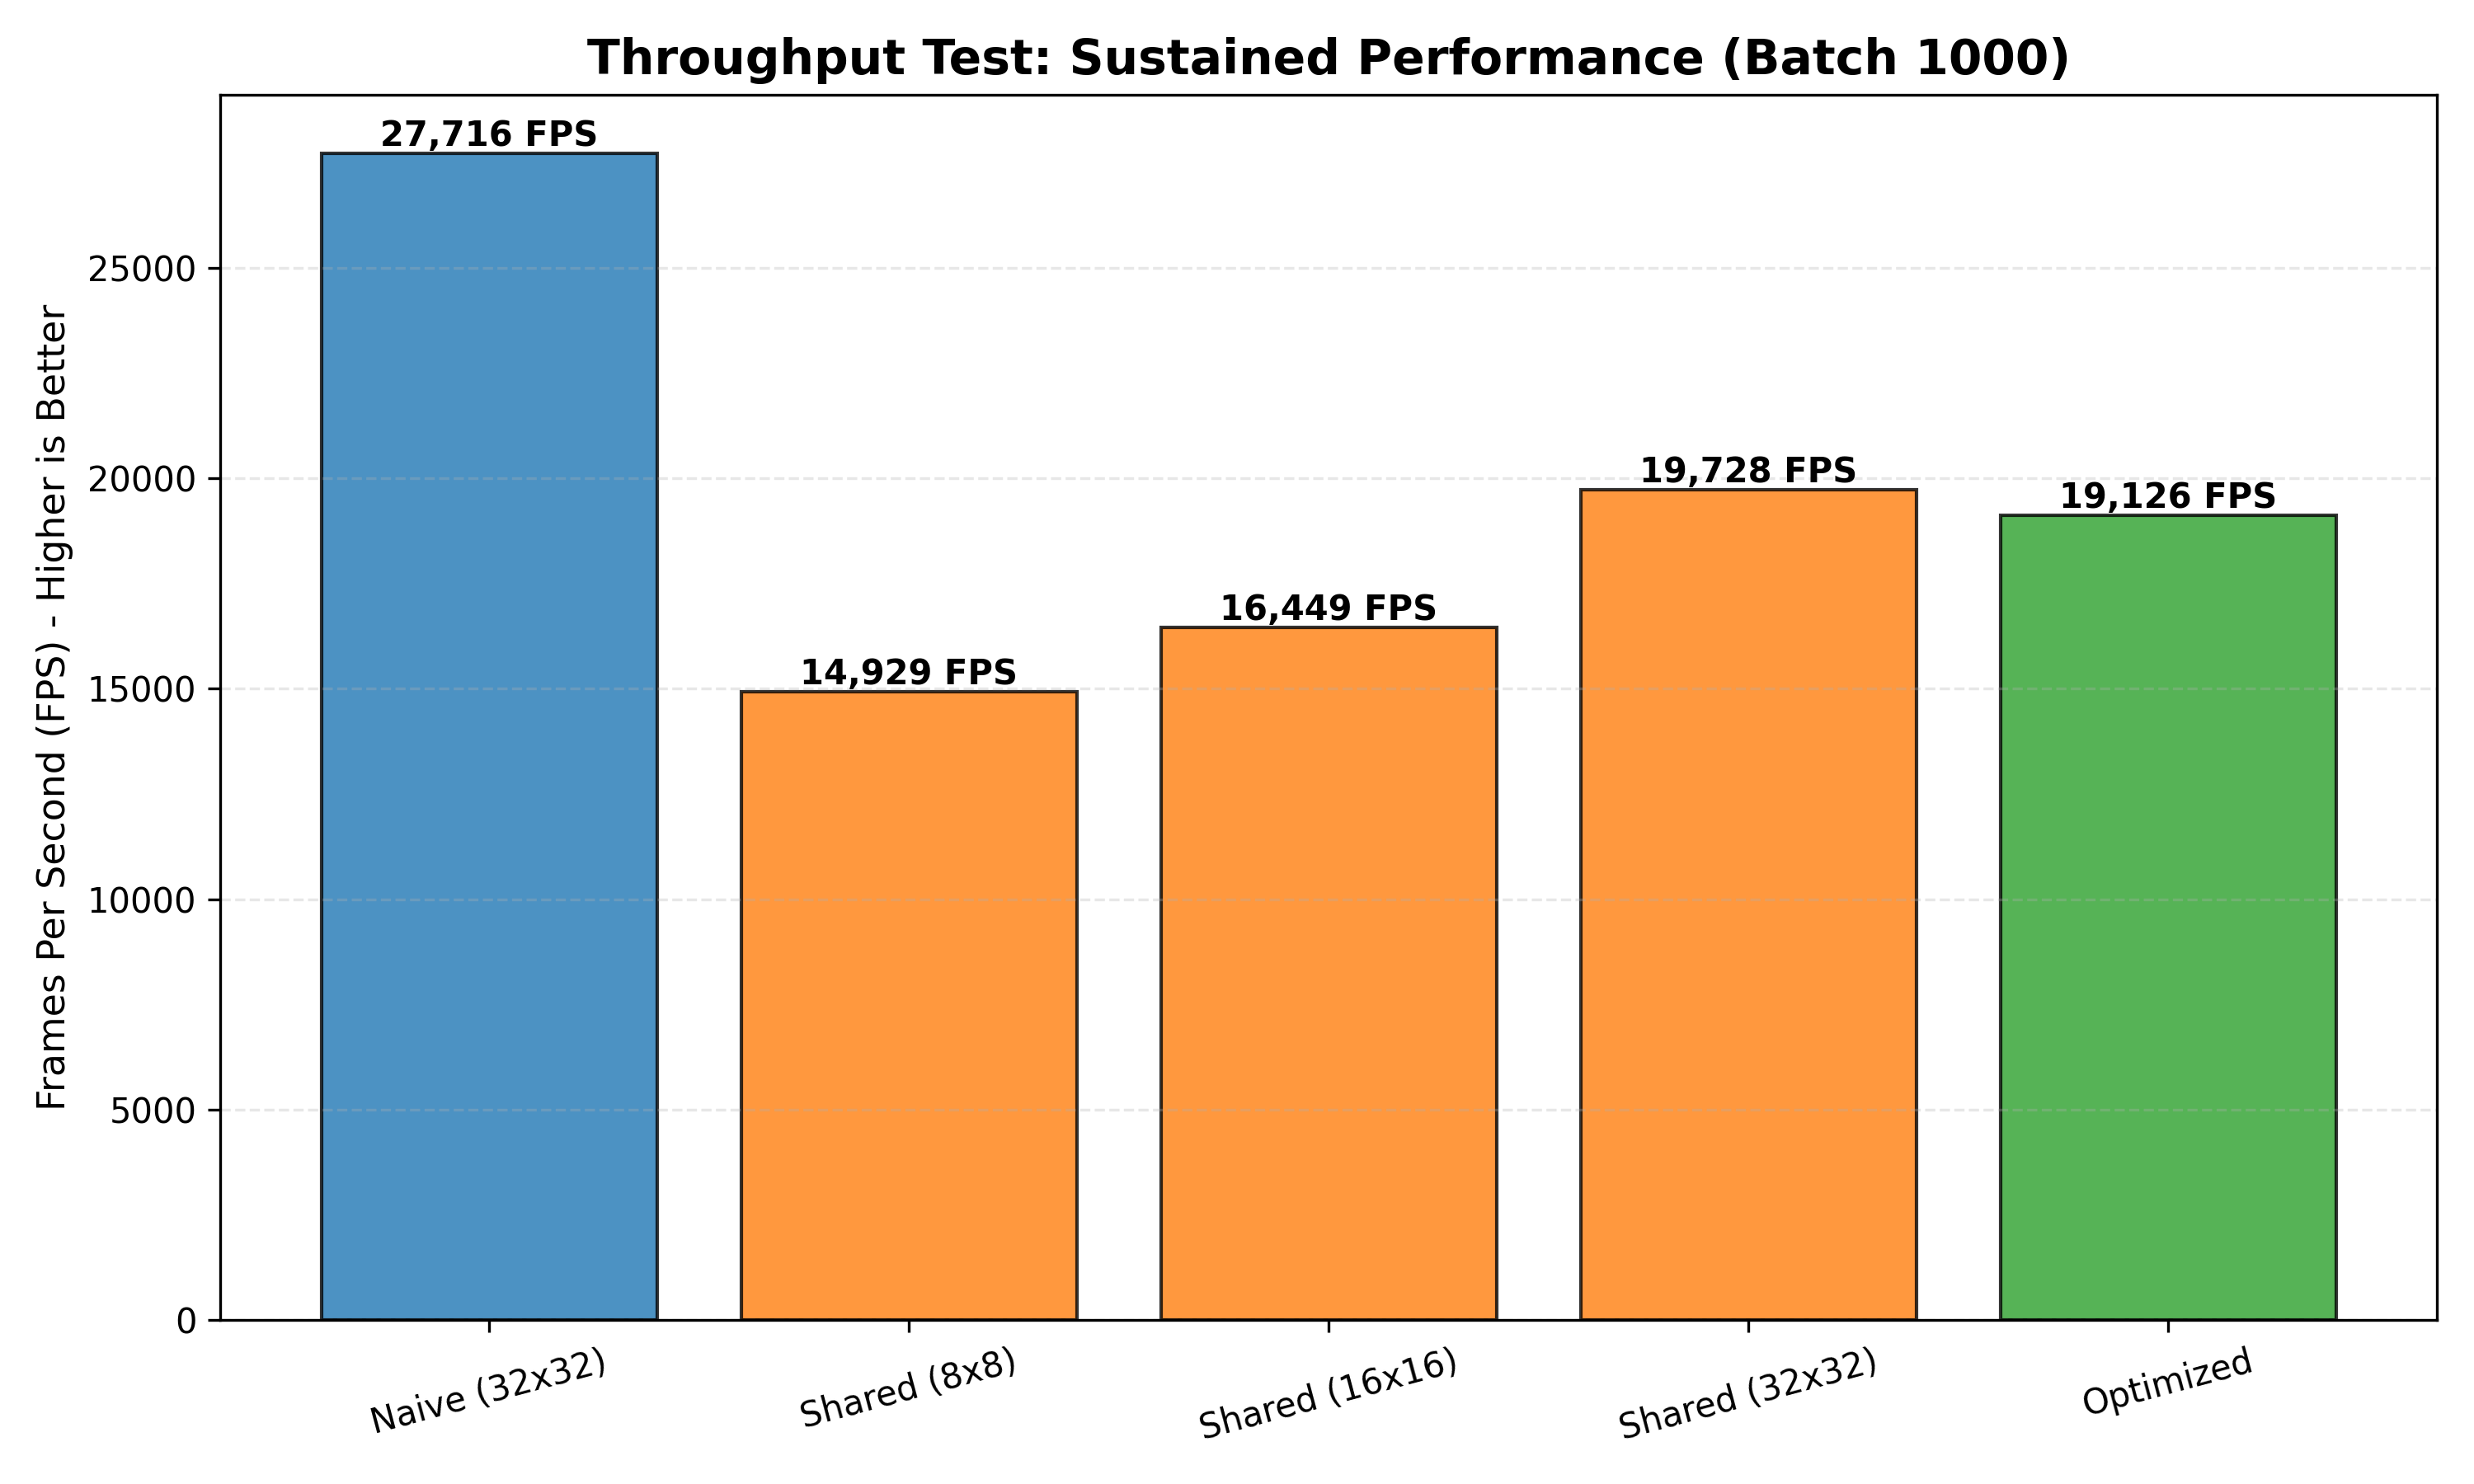


[DISPLAY] 6. Final Validation: CPU vs GPU Speedup
          [Source: Chart_4_CPU_vs_GPU.png]


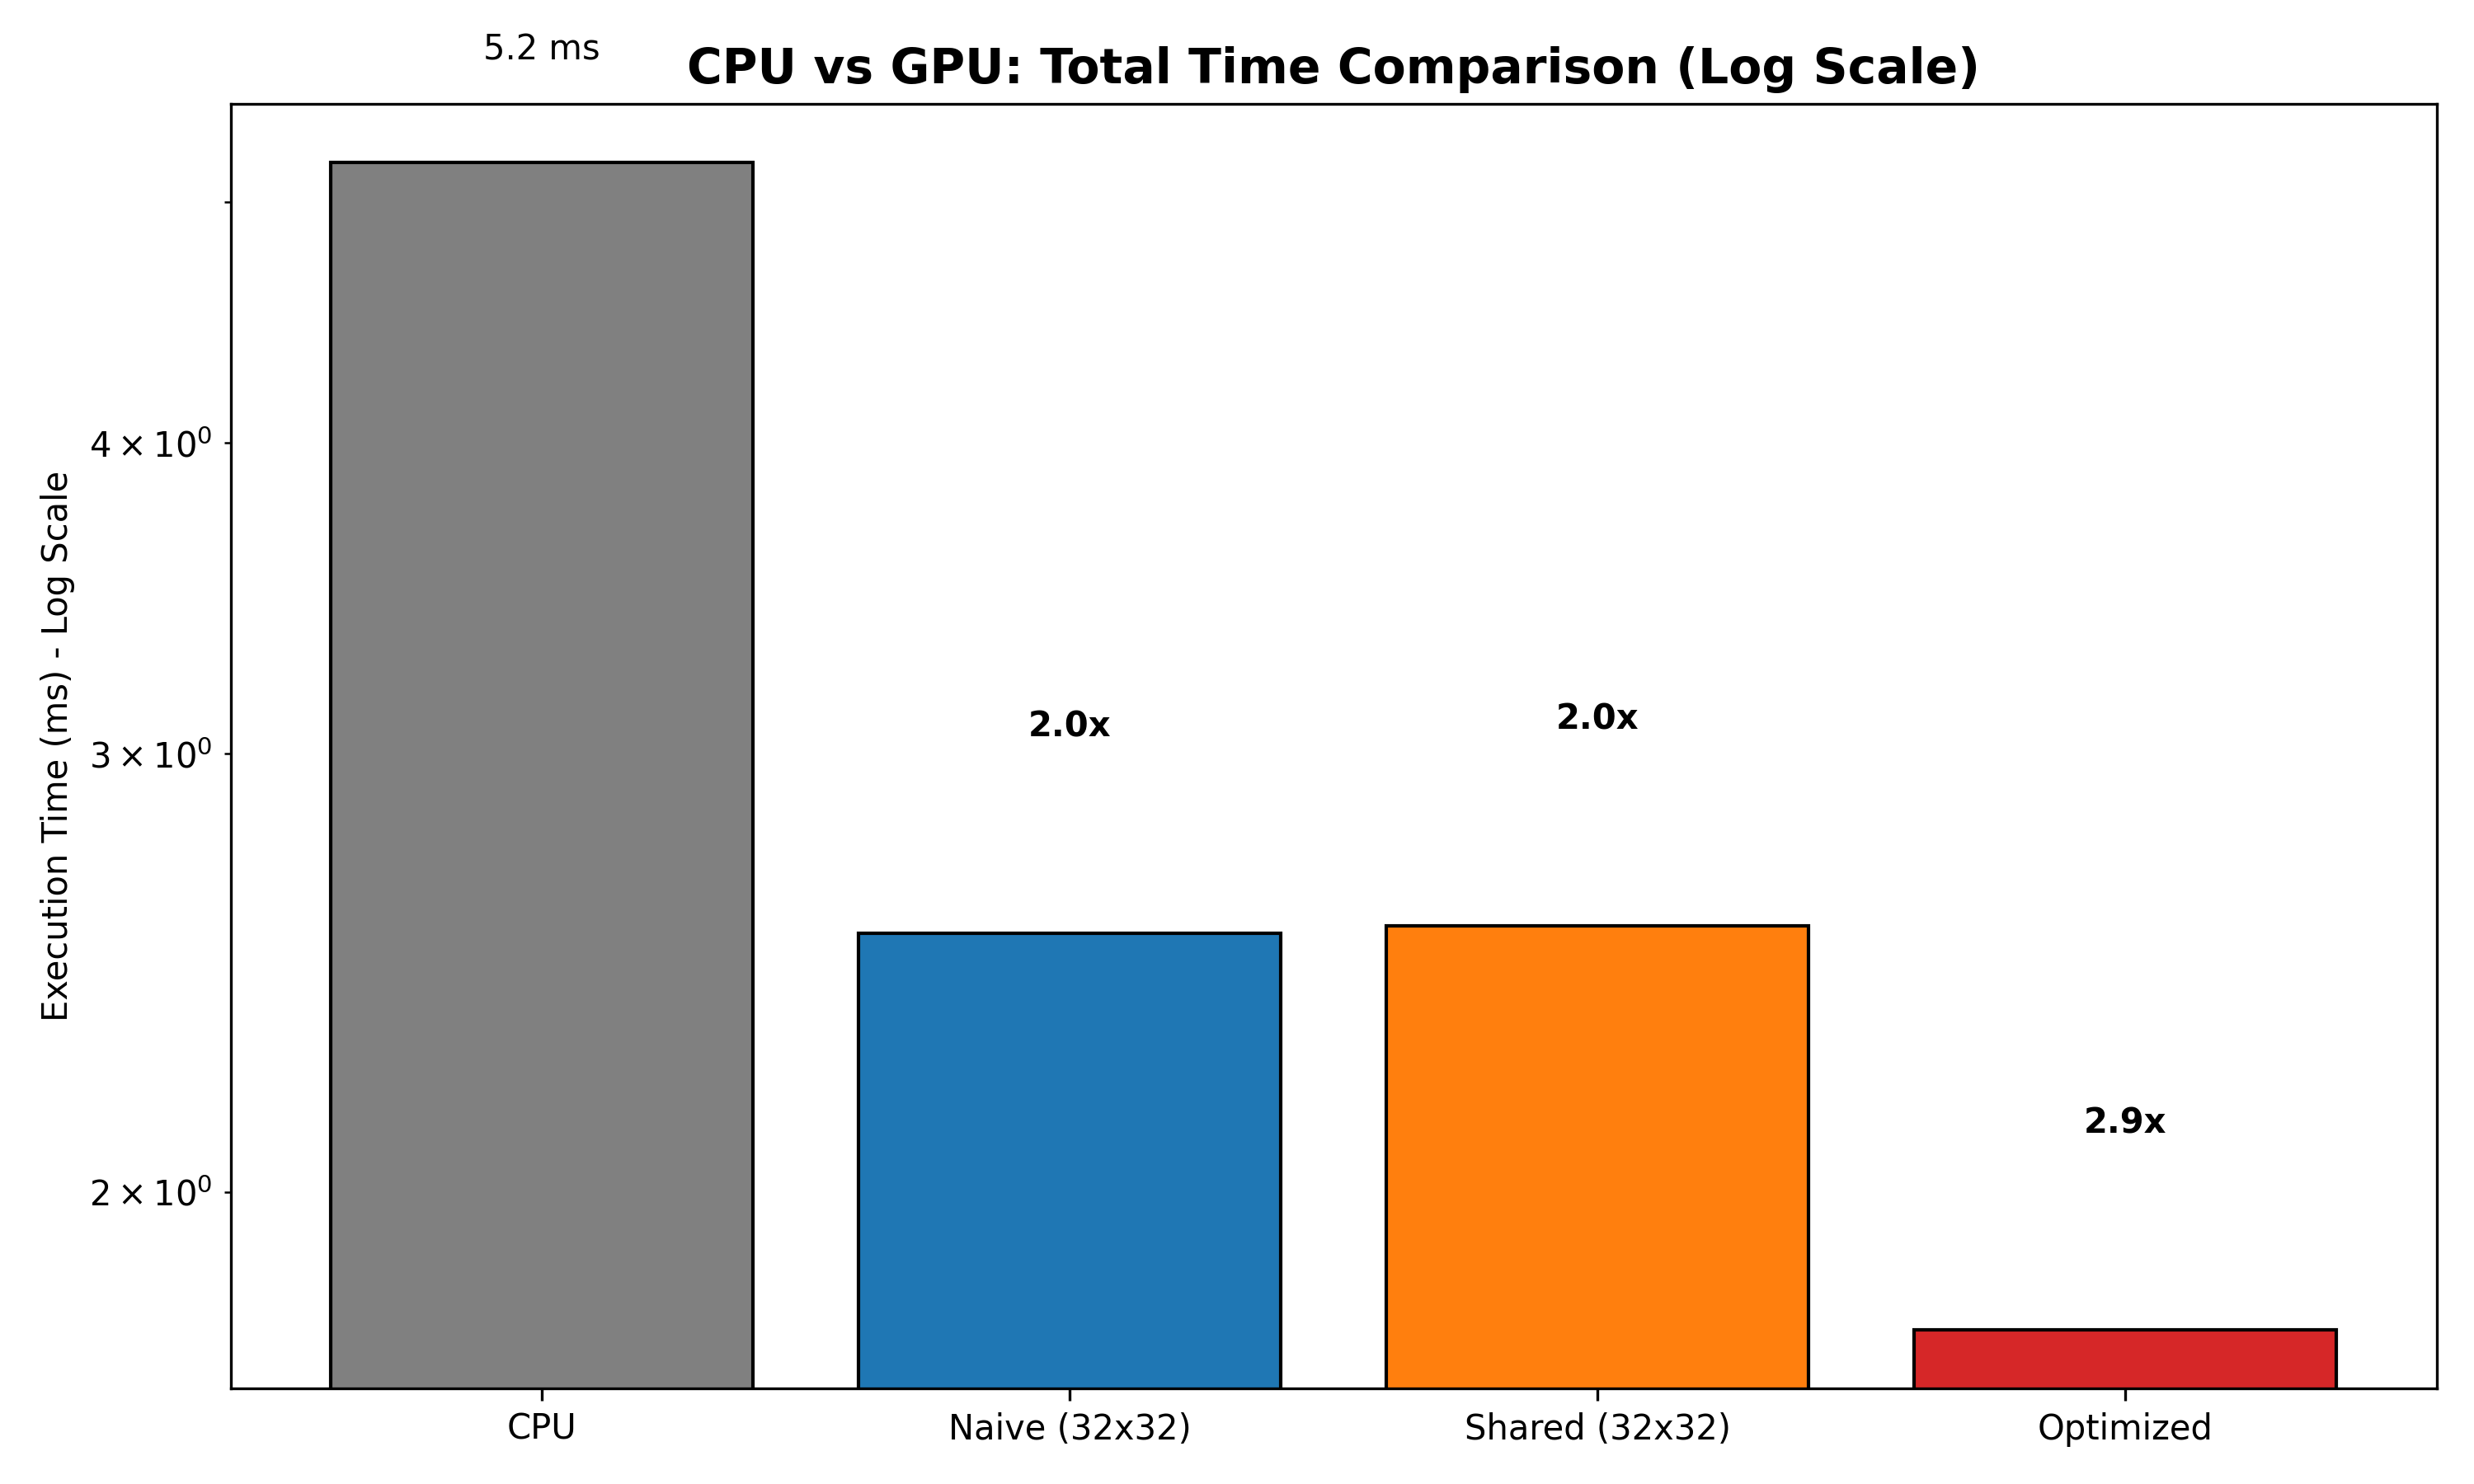


[DISPLAY] 7. Statistical Distribution of Risk Values
          [Source: Grafico_Distribuzione_Rischio.png]


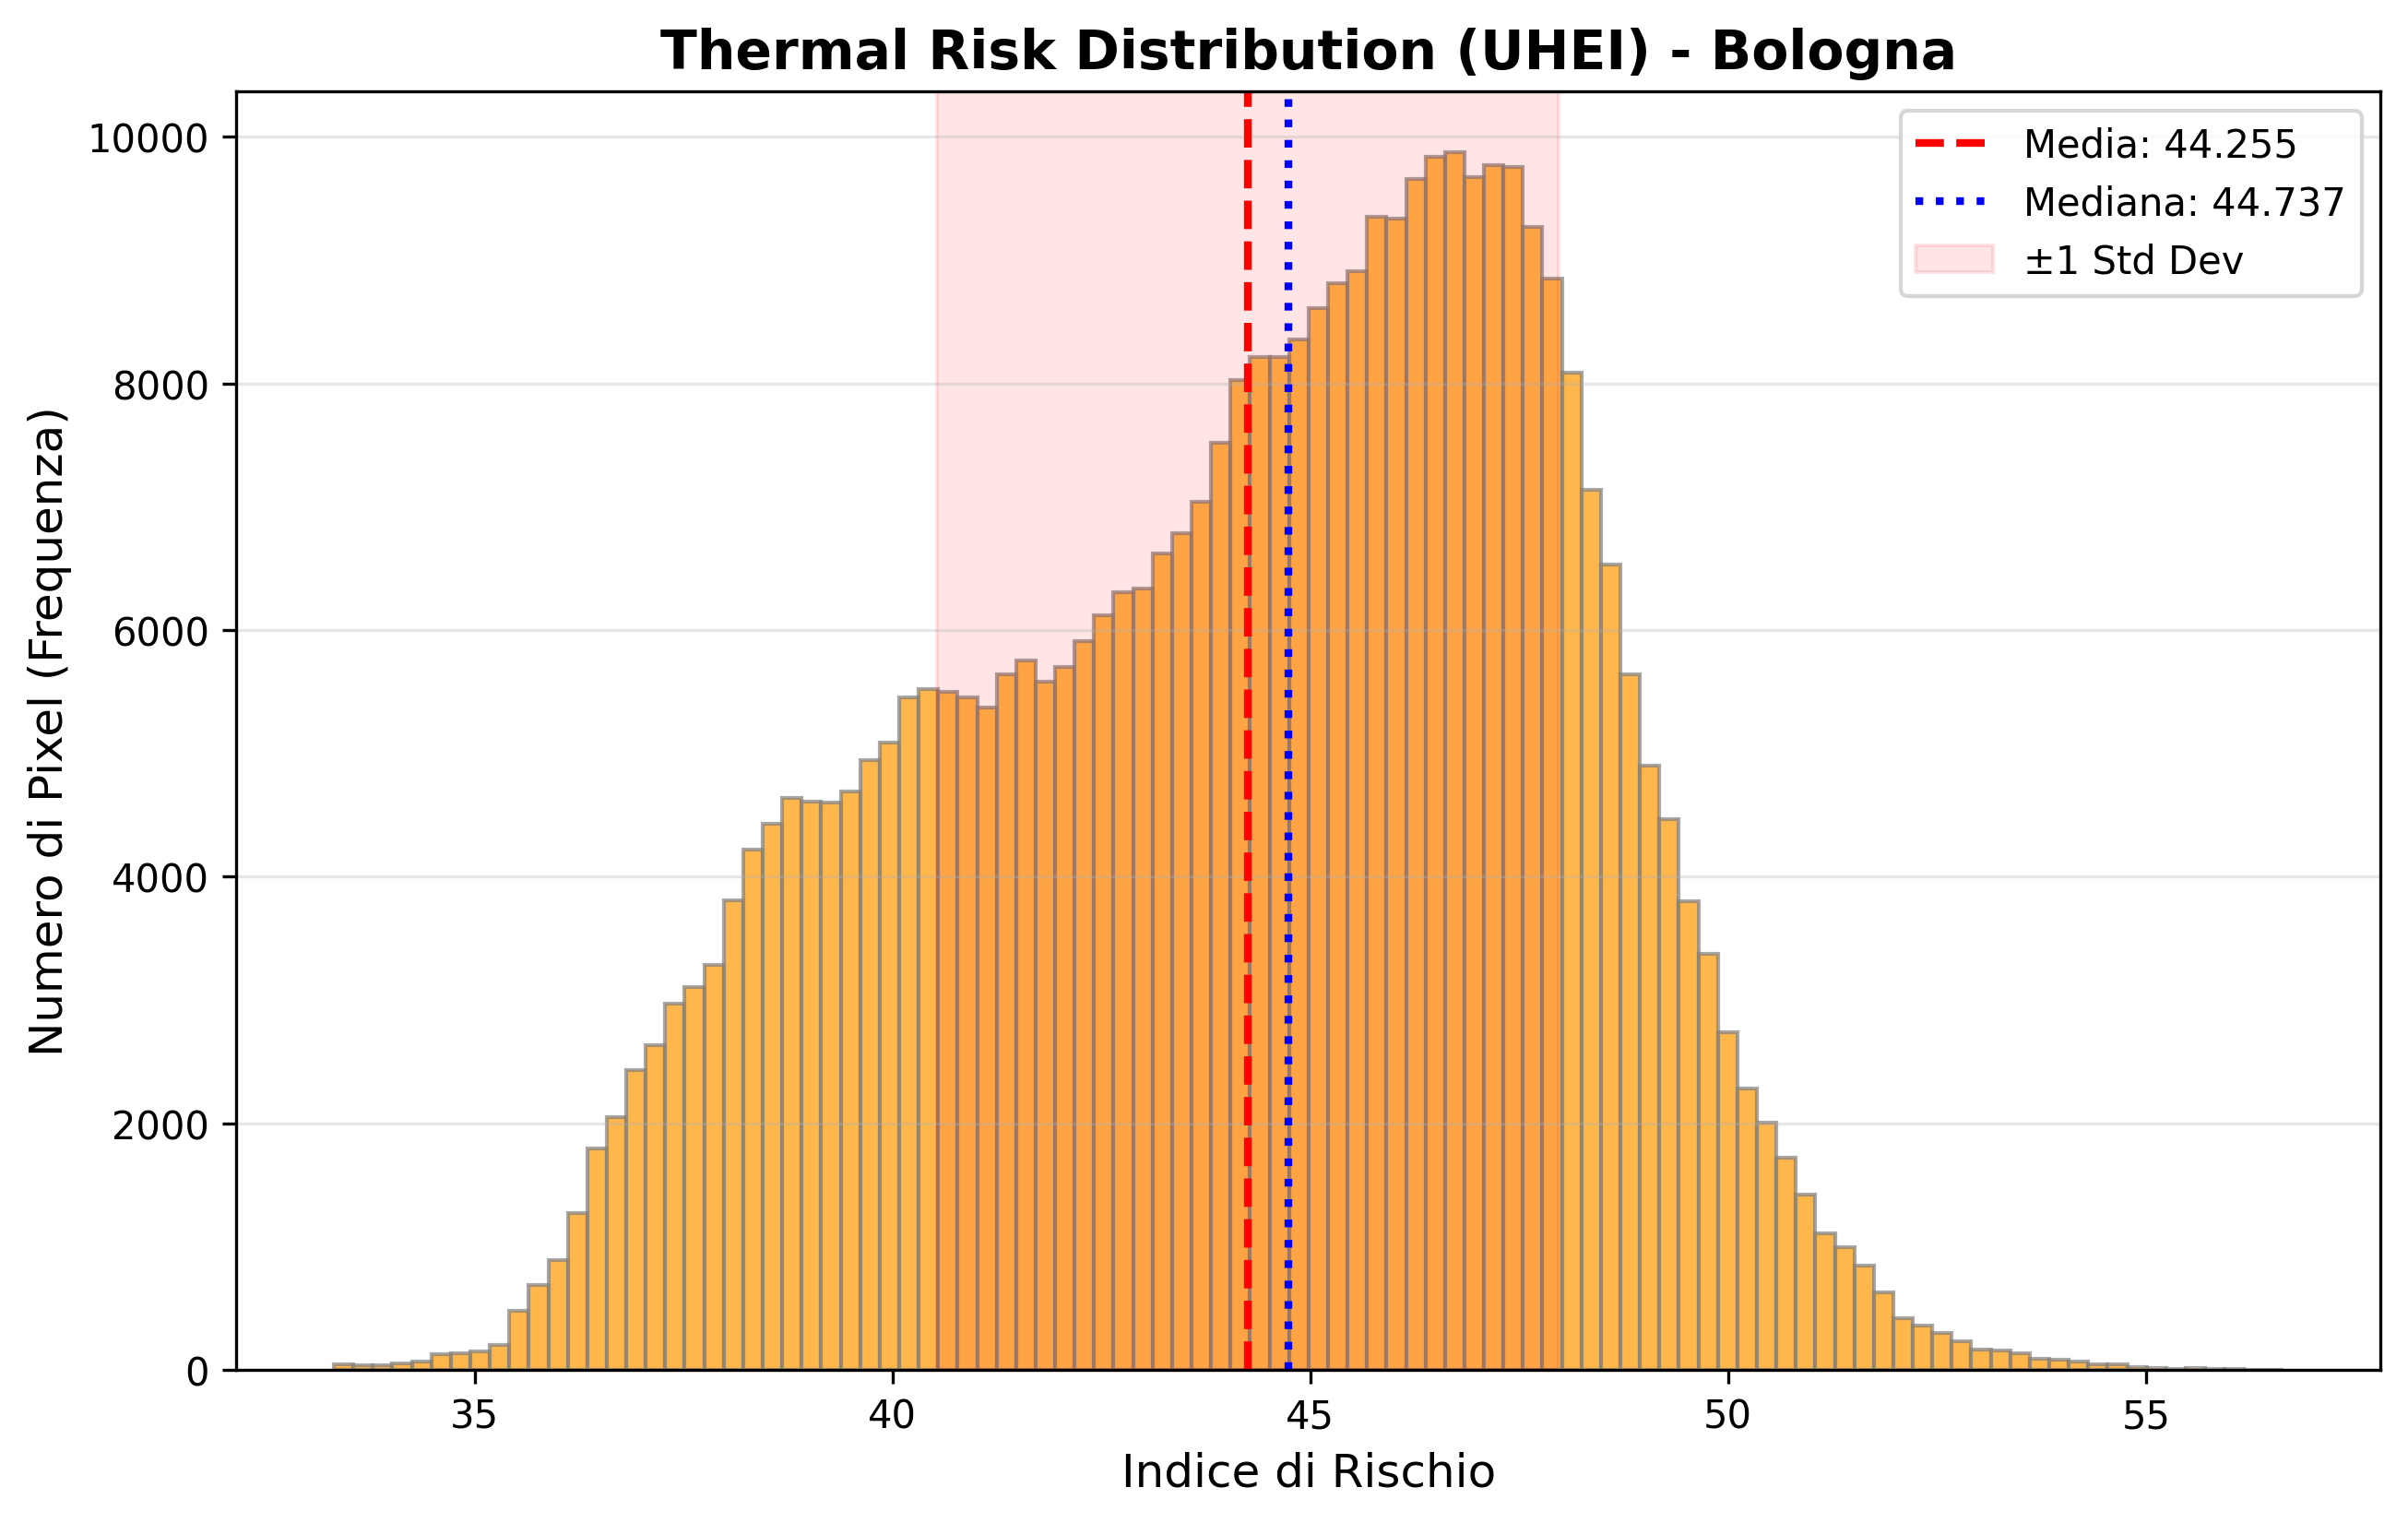


[DISPLAY] 8. Scientific Output Map (Raw Float32)
          [Source: Mappa_Rischio_Raw.png]


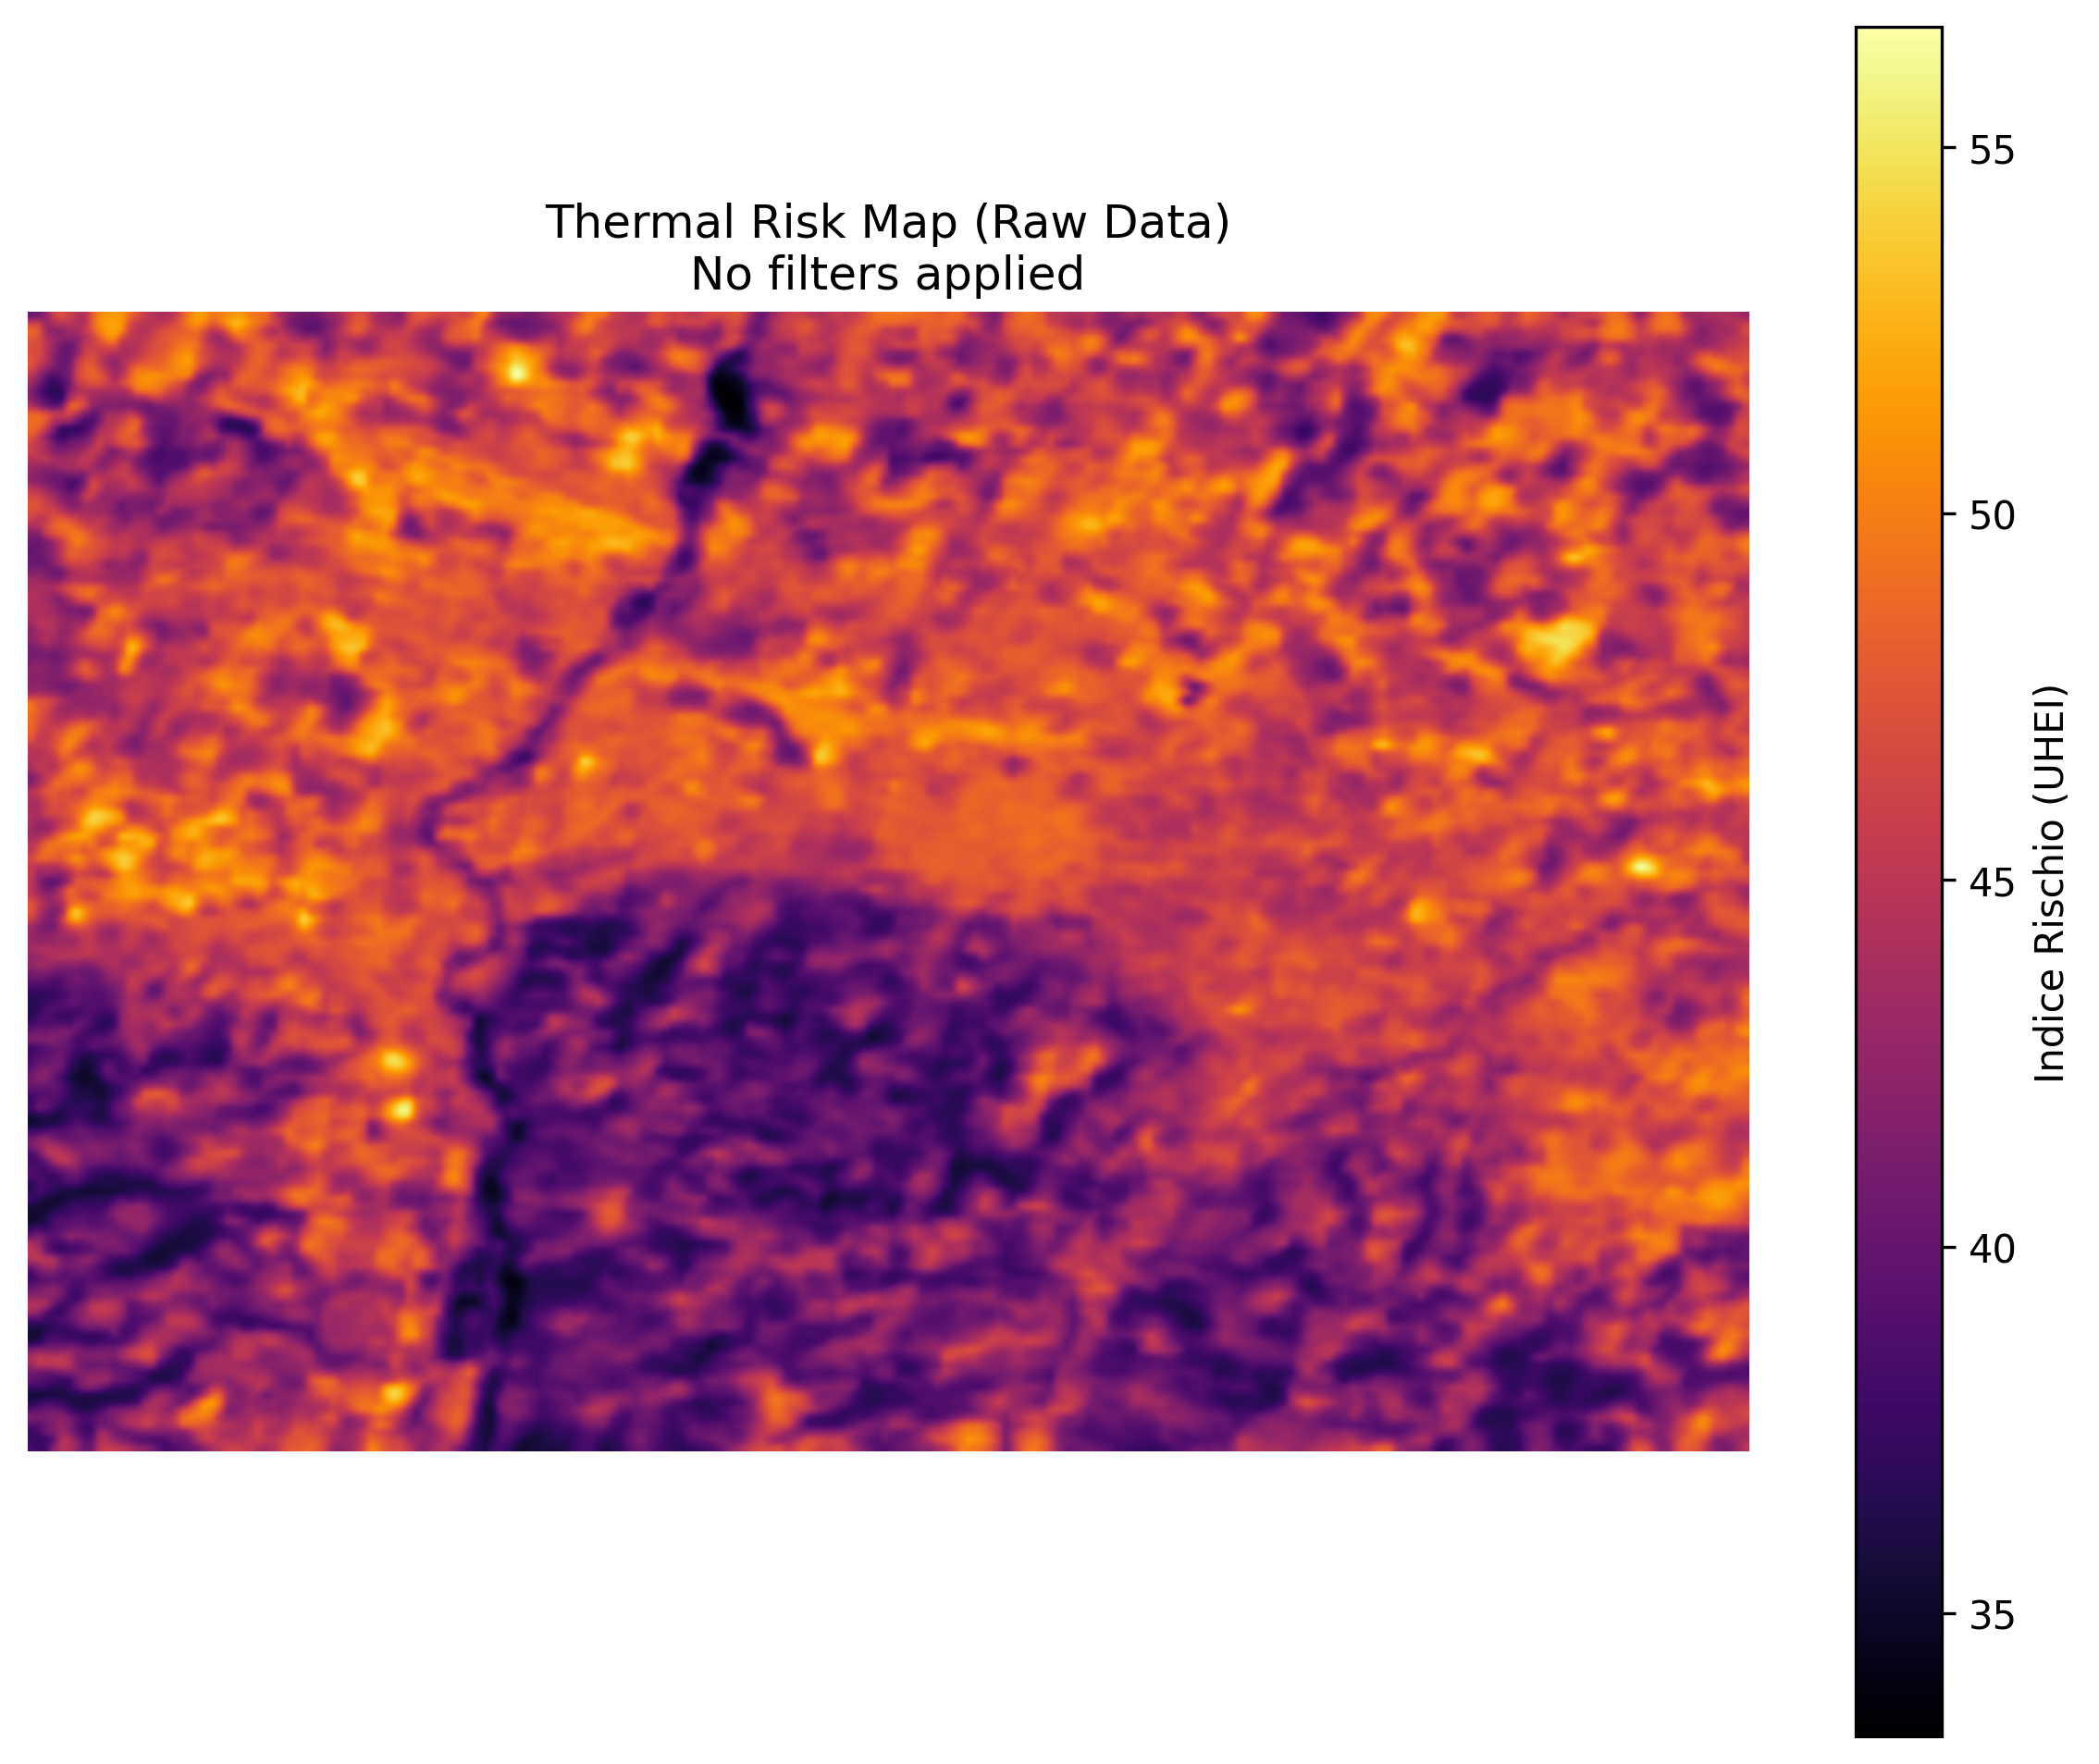


[DISPLAY] 9. Divulgative Map (High Contrast Visualization)
          [Source: Mappa_Rischio_Pro.png]


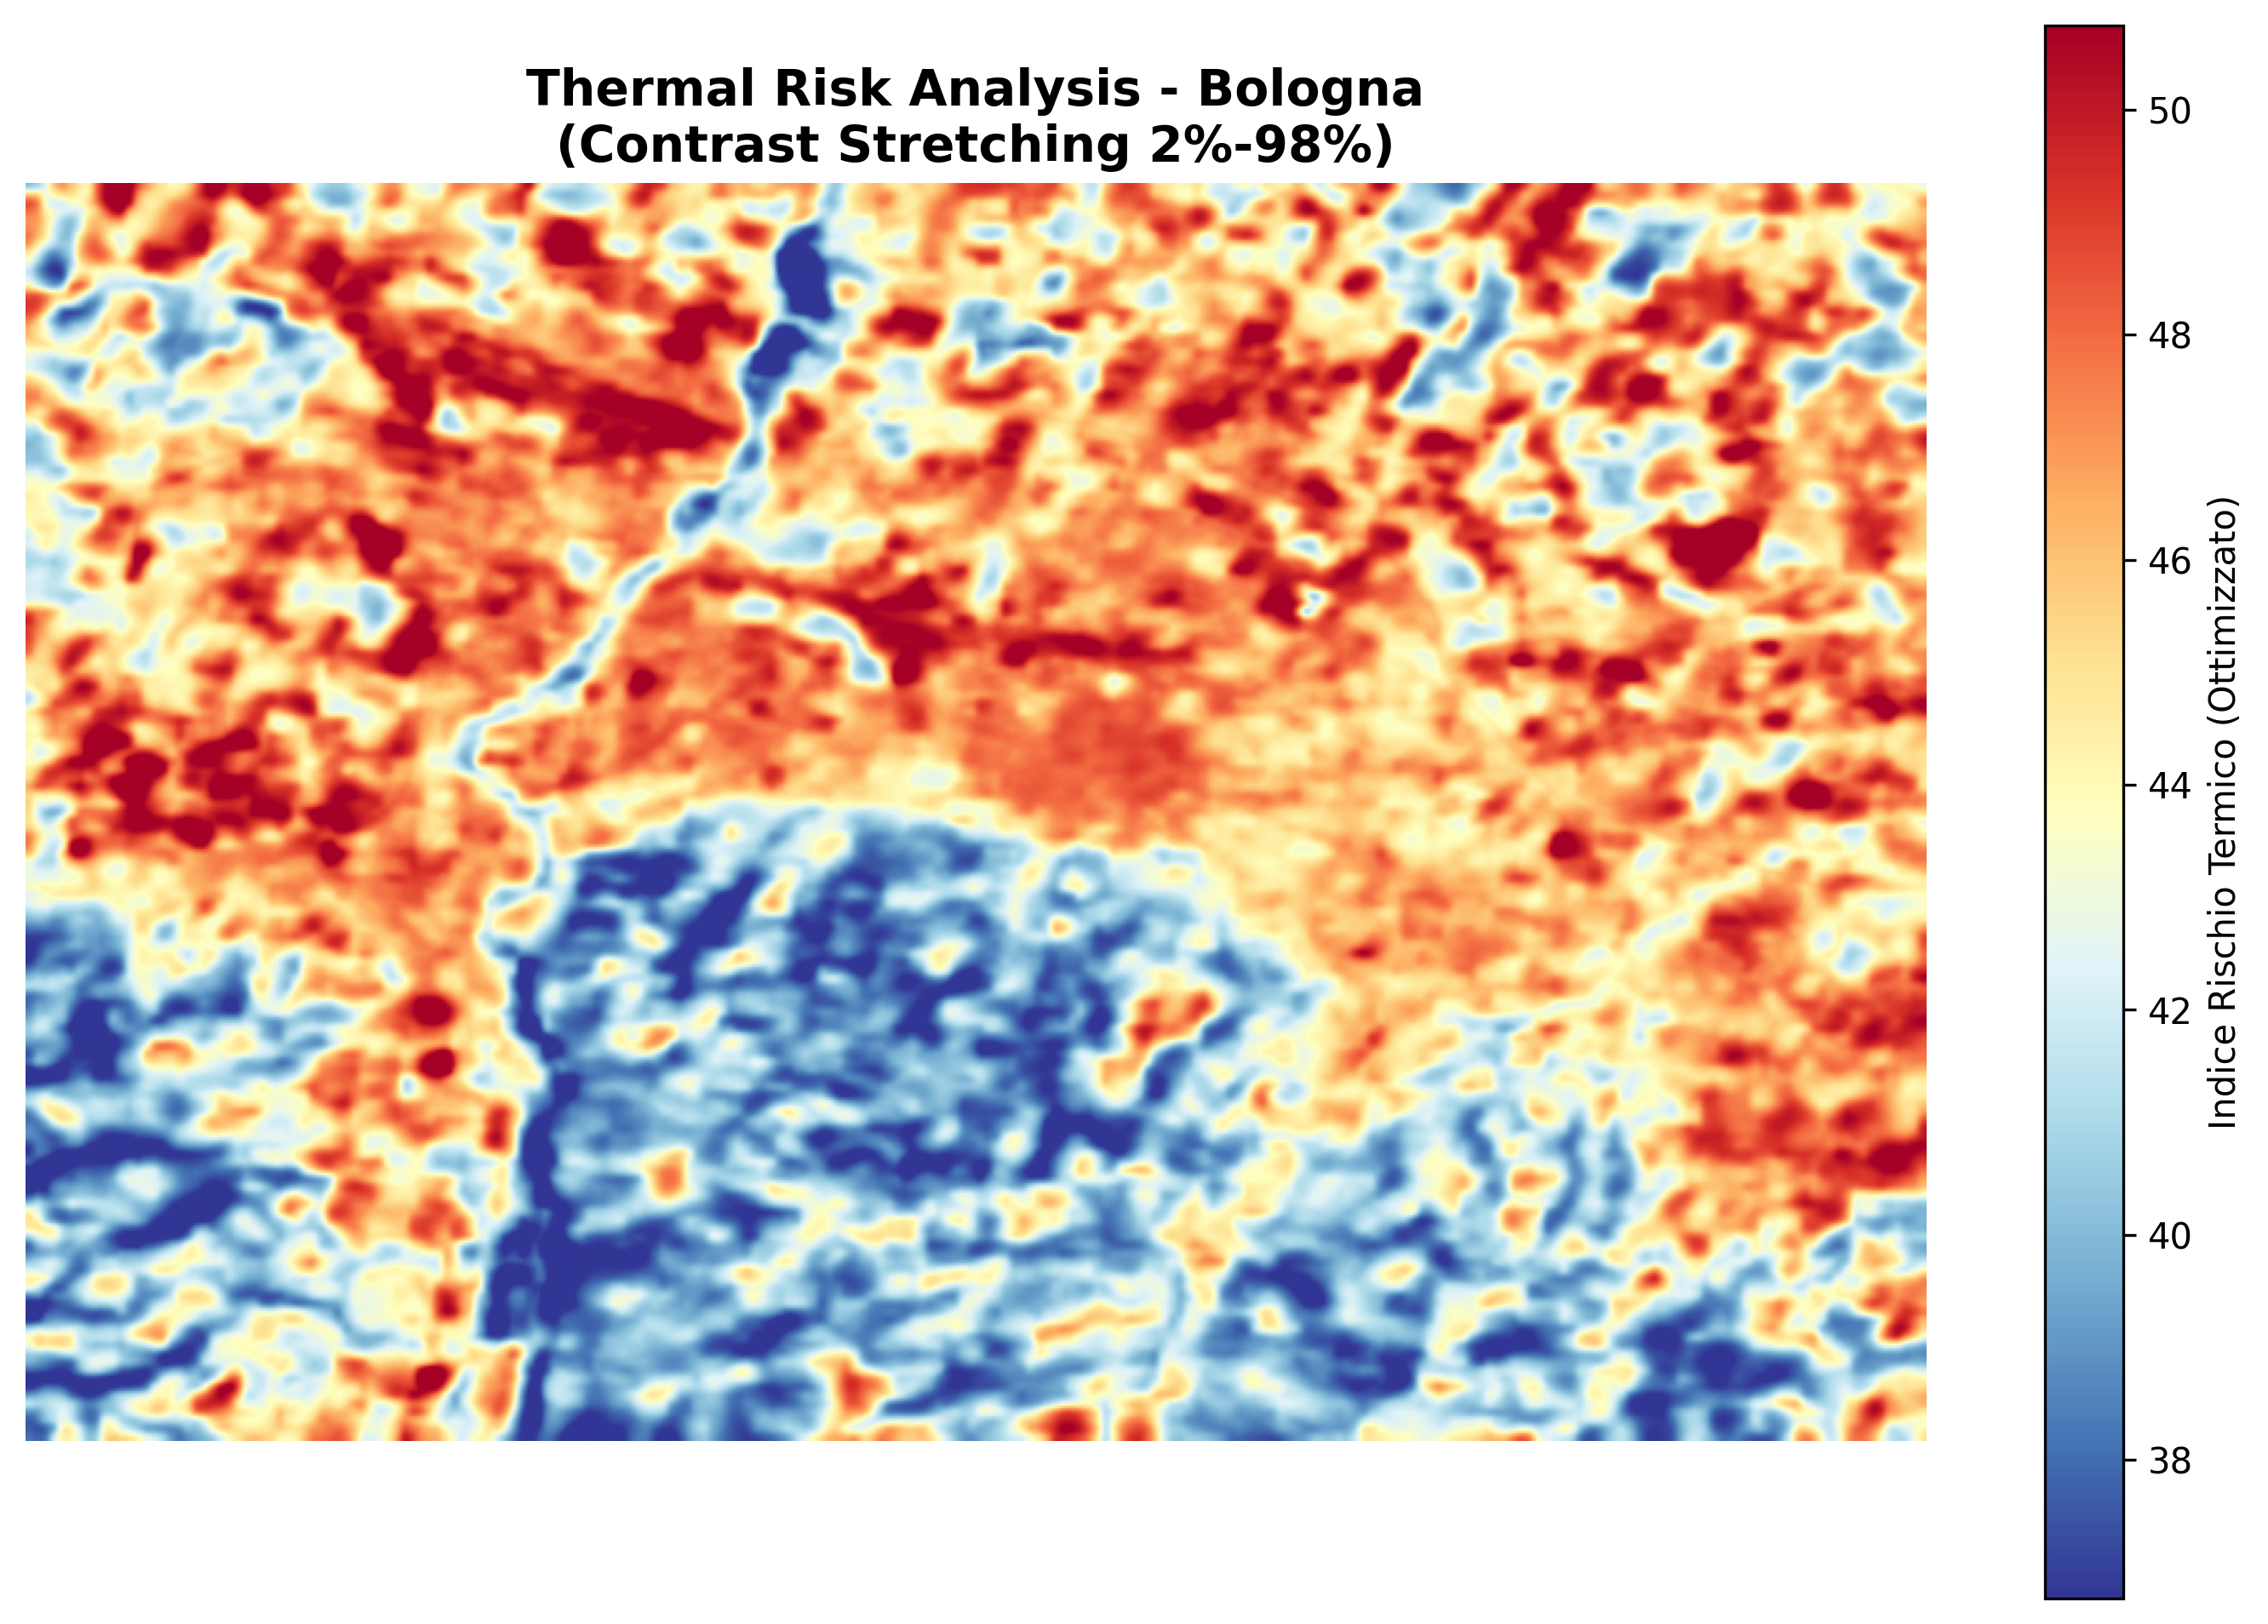


[PHASE 12] INTERACTIVE WEB-GIS GENERATION
[INFO] Initializing Folium engine for geospatial rendering...
[INFO] Phase 12: Interactive geospatial visualization (Web GIS)
[INFO] Preparing interactive map (Dimensions: 758x502)...
[INFO] Generating colored overlay...
[INFO] Computing geographic coordinates...
[INFO] GeoJSON boundaries found.
[INFO] Map saved to disk: ./Mappa_Bologna_Completa.html
[SUCCESS] Interactive map object created successfully.
[DISPLAY] Rendering interactive widget...



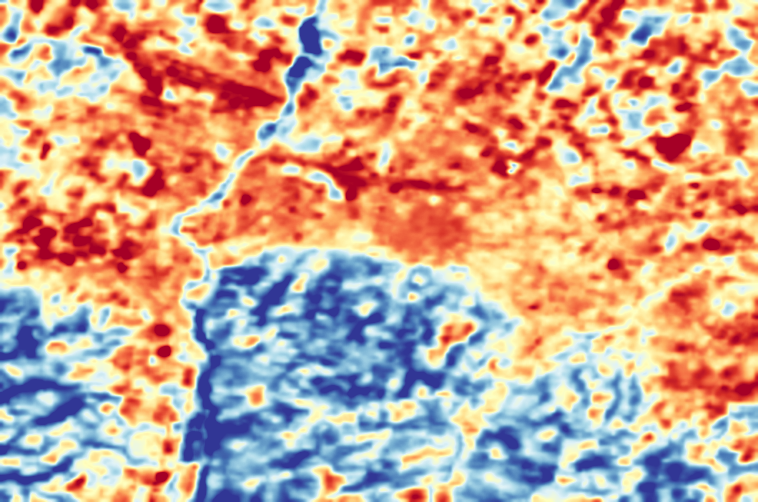

In [ ]:
import os
import sys
from IPython.display import Image, display

print("=====================================================================")
print("[PHASE 9-12] ANALYTICAL VISUALIZATION AND REPORT GENERATION")
print("=====================================================================")

print("[INFO] Executing plotting scripts to generate static artifacts...")

# 1. Esecuzione script di plotting (Sopprimiamo l'output di console per pulizia)
!python3 scripts/plot_performance_charts.py > /dev/null 2>&1
!python3 scripts/plot_histogram.py > /dev/null 2>&1
!python3 scripts/plot_raw_map.py > /dev/null 2>&1
!python3 scripts/plot_pro_map.py > /dev/null 2>&1

# Eseguiamo il Roofline solo se lo script esiste (opzionale ma raccomandato)
if os.path.exists("scripts/plot_roofline.py"):
    !python3 scripts/plot_roofline.py > /dev/null 2>&1

print("[SUCCESS] All charts generated. Rendering gallery below.")
print("---------------------------------------------------------------------")

def show_image(filename, title):
    if os.path.exists(filename):
        print(f"\n[DISPLAY] {title}")
        print(f"          [Source: {filename}]")
        display(Image(filename))
    else:
        print(f"[WARN] Artifact not found: '{filename}' (Check script output)")

# --- A. ANALISI ARCHITETTURALE & COLli DI BOTTIGLIA ---
if os.path.exists("Roofline_Model.png"):
    show_image('Roofline_Model.png', '1. Roofline Model Analysis (Compute vs Memory Bound)')

show_image('Impact_of_Data_Transfer.png', '2. System Bottleneck Analysis (PCIe Overhead)')

# --- B. ANALISI KERNEL & OTTIMIZZAZIONE ---
show_image('Chart_1_Sensitivity.png', '3. Block Size Sensitivity Analysis (Occupancy)')
show_image('Chart_3_Tradeoff.png', '4. Latency vs. Throughput Trade-off')

# --- C. PERFORMANCE DI SISTEMA ---
show_image('Chart_2_Throughput_FPS.png', '5. Throughput Benchmark (Frames Per Second)')
show_image('Chart_4_CPU_vs_GPU.png', '6. Final Validation: CPU vs GPU Speedup')

# --- D. ANALISI DATI E RISULTATI ---
show_image('Grafico_Distribuzione_Rischio.png', '7. Statistical Distribution of Risk Values')
show_image('Mappa_Rischio_Raw.png', '8. Scientific Output Map (Raw Float32)')
show_image('Mappa_Rischio_Pro.png', '9. Divulgative Map (High Contrast Visualization)')

print("\n=====================================================================")
print("[PHASE 12] INTERACTIVE WEB-GIS GENERATION")
print("=====================================================================")

# 2. MAPPA INTERATTIVA
print("[INFO] Initializing Folium engine for geospatial rendering...")

# Setup path per import
sys.path.append('.')
from scripts import generate_web_map
import importlib

# Reload per sicurezza (utile se modifichi lo script senza riavviare il kernel)
importlib.reload(generate_web_map)

# Generazione Oggetto Mappa
try:
    my_map = generate_web_map.create_interactive_map_with_borders()
    print("[SUCCESS] Interactive map object created successfully.")
    print("[DISPLAY] Rendering interactive widget...")
except Exception as e:
    print(f"[ERROR] Failed to generate interactive map: {e}")
    my_map = None

# Render finale
my_map